In [ ]:
pip install rasterio

In [ ]:
pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from osgeo import gdal
import sys
import os
from glob import glob
from matplotlib.colors import ListedColormap
import plotly.graph_objects as go
# To show the image
import rasterio
from rasterio.plot import show
# plot hists
import earthpy.plot as ep
import earthpy as et
import earthpy.spatial as es

In [ ]:
## Read tif image as Array :

def tif_to_matrix(path):
  src_ds = gdal.Open(path)
  data = src_ds.ReadAsArray()
  return data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area3.csv')

In [ ]:
df.head()

,date_time,soil_moisture_depth_0.050000,depth,hour,Image_name
0,2017-04-02,0.079,0.05,10:00:00,20170402T110651_20170402T111830_T29TQF.tif
1,2017-04-07,0.079,0.05,10:00:00,20170407T111049_20170407T111824_T29TQF.tif
2,2017-04-12,0.081,0.05,10:00:00,20170412T110621_20170412T111708_T29TQF.tif
3,2017-05-02,0.066,0.05,10:00:00,20170502T110621_20170502T110937_T29TQF.tif
4,2017-05-22,0.085,0.05,10:00:00,20170522T110621_20170522T110912_T29TQF.tif


In [ ]:
df.describe()

,soil_moisture_depth_0.050000,depth
count,164.000000,1.640000e+02
mean,0.103866,5.000000e-02
std,0.047101,1.183225e-16
min,0.041000,5.000000e-02
25%,0.061000,5.000000e-02
50%,0.090500,5.000000e-02
75%,0.143750,5.000000e-02
max,0.209000,5.000000e-02


In [ ]:
 ## Collect images paths :

 S_sentinel_bands = glob("/content/drive/MyDrive/All_3_areas_cropped/*QF.tif")

In [ ]:
S_sentinel_bands[0]

'/content/drive/MyDrive/All_3_areas_cropped/Area1_20170407T111049_20170407T111824_T29TQF.tif'

In [ ]:
data = tif_to_matrix(S_sentinel_bands[0])

In [ ]:
data.shape

(12, 31, 31)

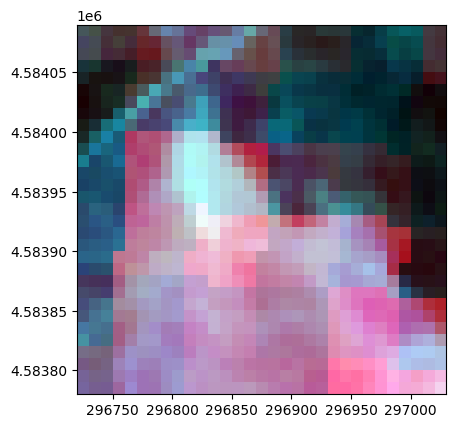

<Axes: >

In [ ]:
src = rasterio.open(S_sentinel_bands[0])
show(src)

In [ ]:
# =========================================
# S2DR3 batch processing in Google Colab
# Reads points/dates from CSV and saves outputs to Drive
# =========================================



import os
import shutil
import pandas as pd

# If the package is available in your environment:
import s2dr3.inferutils

# -----------------------------
# USER SETTINGS
# -----------------------------
# CSV must have these columns:
# id, lon, lat, date
csv_path = "/content/drive/MyDrive/s2dr3_inputs/targets.csv"

# Where you want outputs saved
output_dir = "/content/drive/MyDrive/s2dr3_outputs"
os.makedirs(output_dir, exist_ok=True)

# S2DR3 usually writes to /content/output
work_output_dir = "/content/output"
os.makedirs(work_output_dir, exist_ok=True)

# -----------------------------
# READ INPUTS
# -----------------------------
df = pd.read_csv(csv_path)

required_cols = {"id", "lon", "lat", "date"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# -----------------------------
# RUN S2DR3
# -----------------------------
for _, row in df.iterrows():
    sample_id = str(row["id"])
    lonlat = (float(row["lon"]), float(row["lat"]))
    date = str(row["date"])

    print(f"Processing {sample_id} | {lonlat} | {date}")

    # Run S2DR3 inference
    s2dr3.inferutils.test(lonlat, date)

    # Find generated multispectral GeoTIFF
    ms_file = None
    for root, dirs, files in os.walk(work_output_dir):
        for f in files:
            if f.startswith("S2L2Ax10_") and f.endswith("_MS.tif"):
                ms_file = os.path.join(root, f)
                break
        if ms_file:
            break

    if ms_file is None:
        print(f"No MS output found for {sample_id}")
        continue

    # Rename and move to Drive
    out_name = f"{sample_id}_MS.tif"
    out_path = os.path.join(output_dir, out_name)
    shutil.move(ms_file, out_path)

    print(f"Saved: {out_path}")

print("Done.")

In [ ]:
## Calculate images dimensions :

src.bounds
print("Image width is "+ str(src.bounds[2]-src.bounds[0])+"m, and height is "+ str(src.bounds[3]-src.bounds[1])+"m")
src.width, src.height

Image width is 310.0m, and height is 310.0m


(31, 31)

In [ ]:
## Stack the images bands :

l = []
img = '/content/drive/MyDrive/All_3_areas_cropped/Area1_20170407T111049_20170407T111824_T29TQF.tif'


#for i in S_sentinel_bands[0]:
with rasterio.open(img) as f:
  for i in range (1,13):
    l.append(f.read(i))

arr_st = np.stack(l)

In [ ]:
arr_st.shape

(12, 31, 31)

NameError: name 'data_norm' is not defined

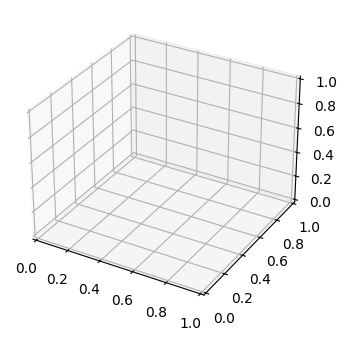

In [ ]:
## 3D Plot of image bands :

import numpy as np
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
z, x, y = data_norm.nonzero()
ax.scatter(x, y, z, c=z, alpha=1)
plt.show()

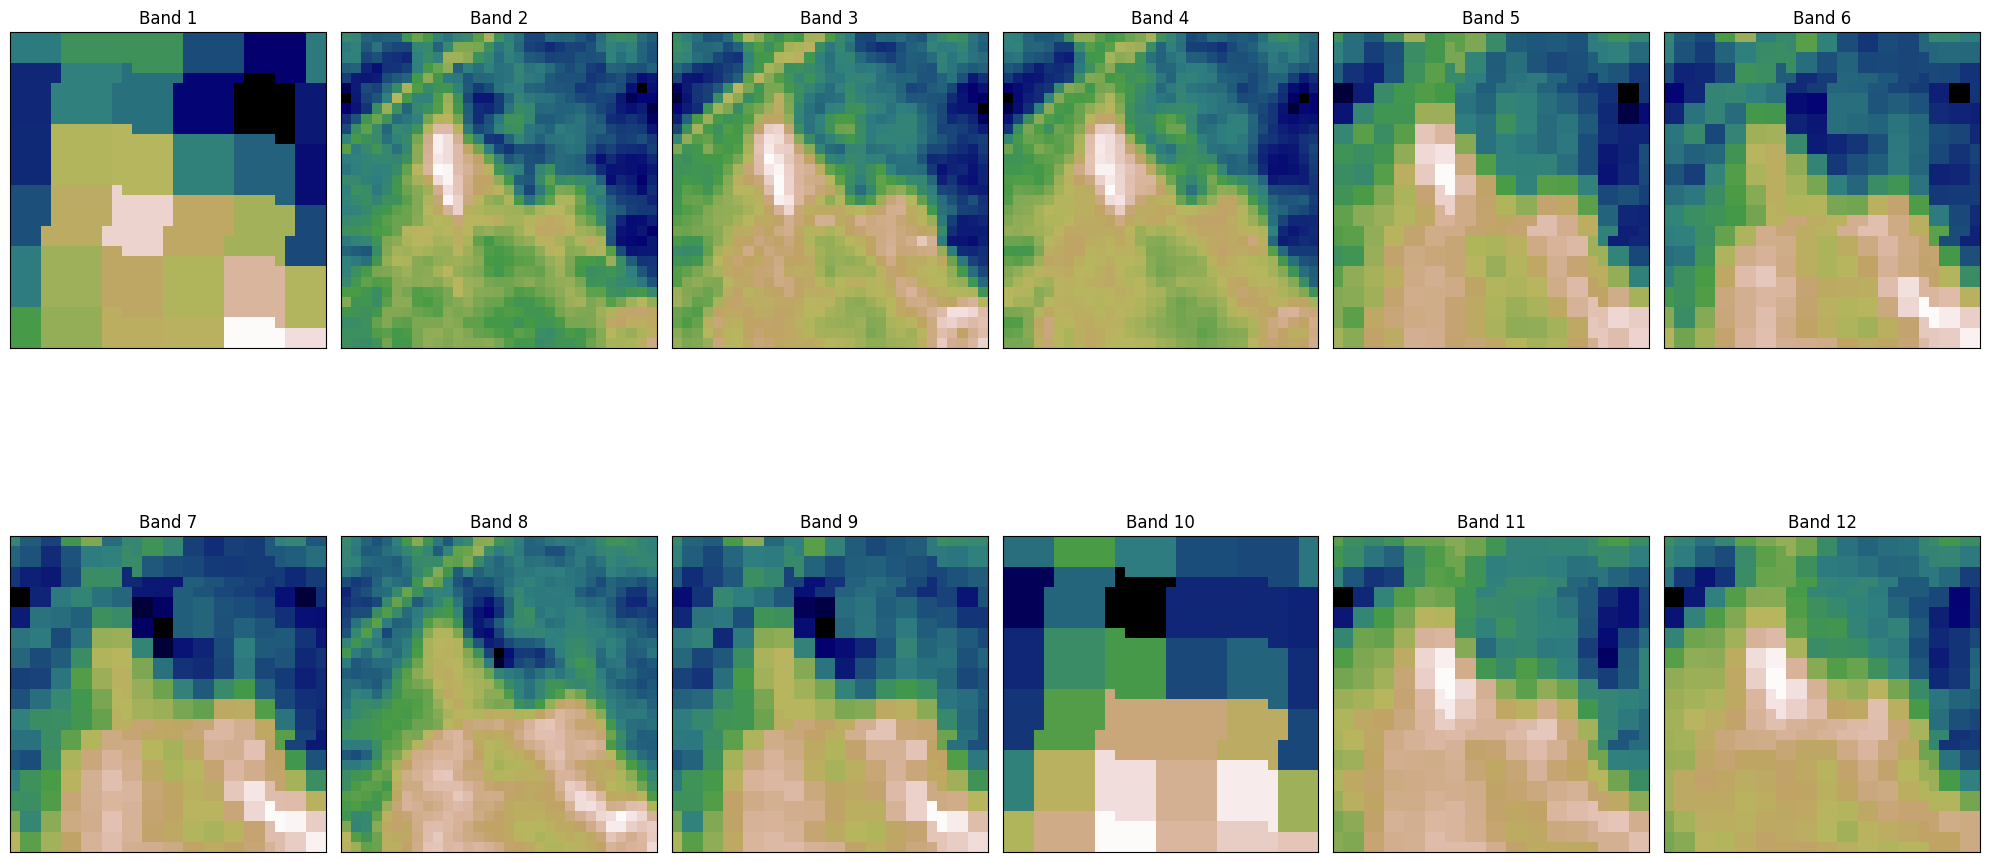

In [ ]:
## Image Bands : Image from March 2017

ep.plot_bands(arr_st, cmap = 'gist_earth', figsize = (20, 12), cols = 6, cbar = False)
plt.show()

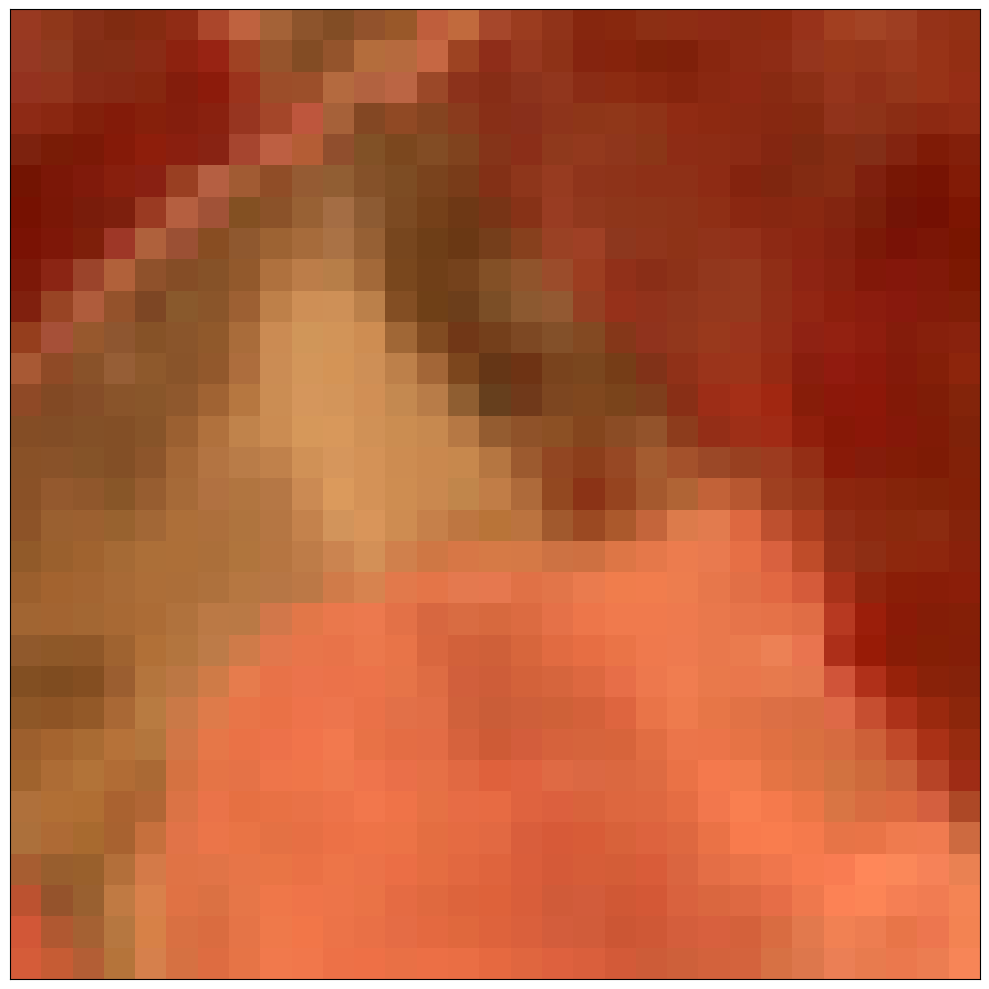

In [ ]:
# Color Infrared (B8, B4, B3) Composite Image : Image from March 2017

ep.plot_rgb(arr_st,
            rgb=(7, 3, 2),
            str_clip=0.2);

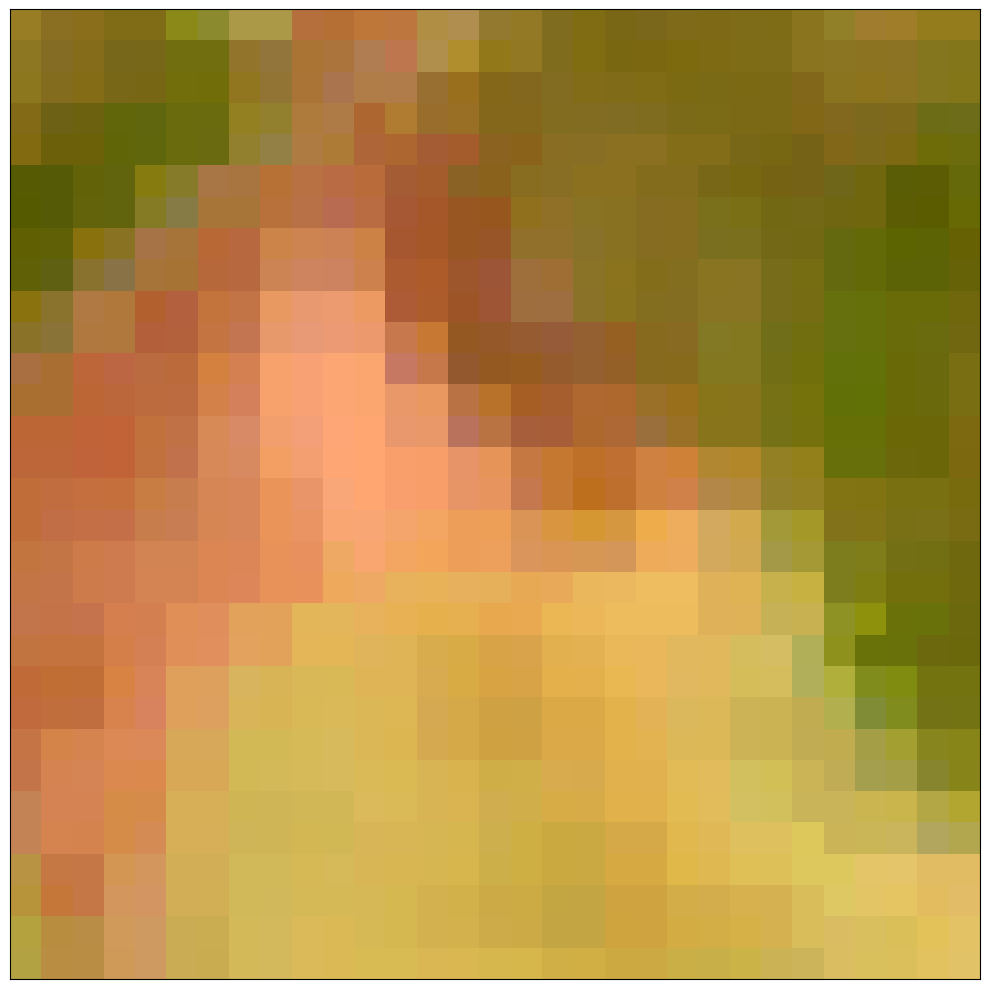

<Axes: >

In [ ]:
# Agriculture (B11, B8, B2) Composite Image : Image from March 2019

ep.plot_rgb(arr_st,
            rgb=(11, 8, 3),
            str_clip=0.2)

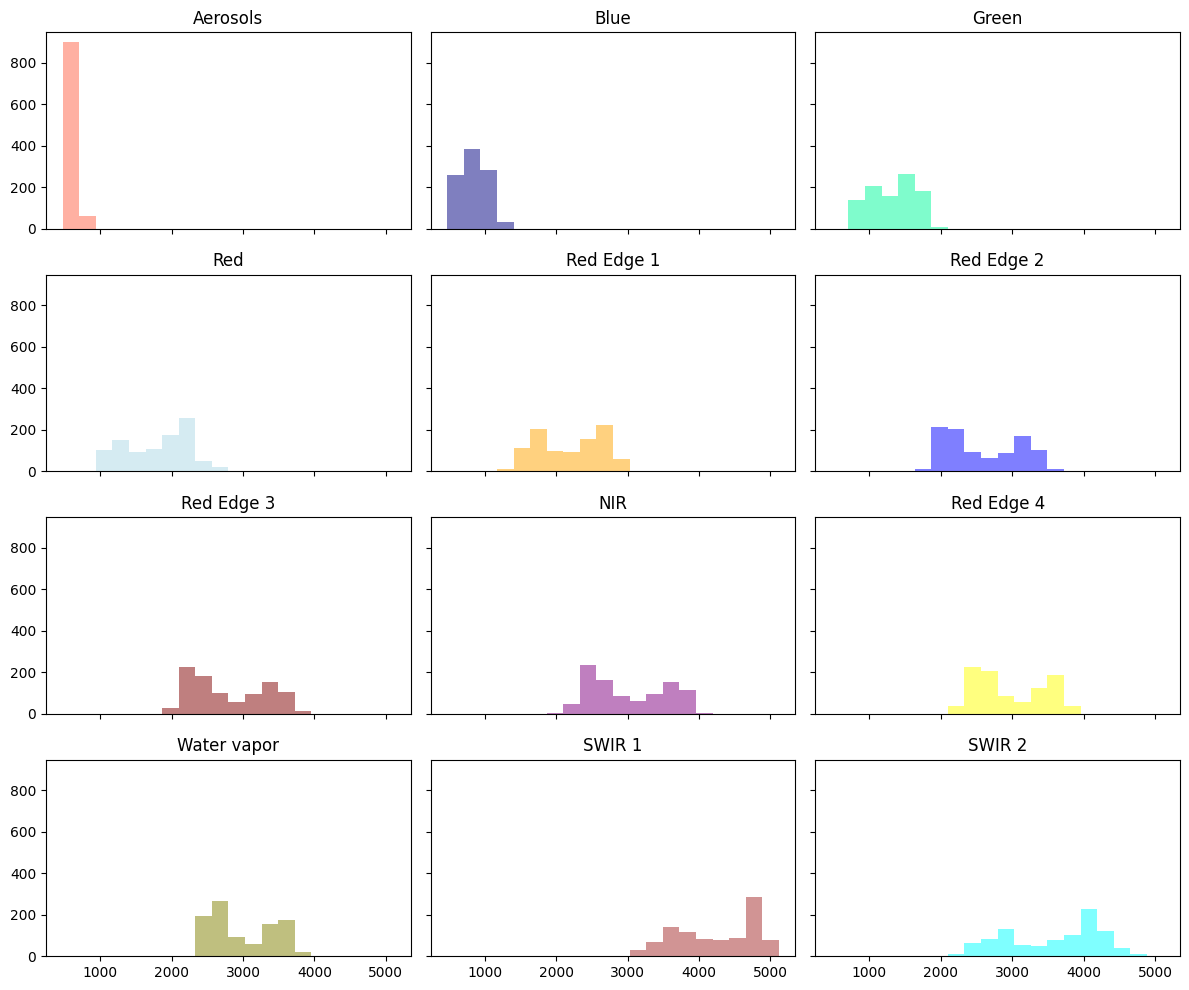

In [ ]:
## Histograms :  Image from March 2019

colors = ['tomato', 'navy', 'MediumSpringGreen', 'lightblue', 'orange', 'blue',
          'maroon', 'purple', 'yellow', 'olive', 'brown', 'cyan']
ep.hist(arr_st,
         colors = colors,
        title=["Aerosols", "Blue", "Green", "Red","Red Edge 1", "Red Edge 2", "Red Edge 3","NIR","Red Edge 4", "Water vapor","SWIR 1", "SWIR 2"],
        cols=3,
        alpha=0.5,
        figsize = (12, 10)
        )

plt.show()

In [ ]:
## Read the images bands as mean of the bands:

list_box = []
for i in range(12):
  list_test = []
  for j in range(len(arr_st[i])):
    list_test.append(arr_st[i][j].mean())
  list_box.append(list_test)

In [ ]:
numpy_array = np.array(list_box)
transpose = numpy_array.T
transpose_list = transpose.tolist()

In [ ]:
bands_data = pd.DataFrame(transpose_list, columns=["Aerosols", "Blue", "Green", "Red","Red Edge 1", "Red Edge 2", "Red Edge 3","NIR","Red Edge 4", "Water vapor","SWIR 1", "SWIR 2"] )


In [ ]:
bands_data.describe()

,Aerosols,Blue,Green,Red,Red Edge 1,Red Edge 2,Red Edge 3,NIR,Red Edge 4,Water vapor,SWIR 1,SWIR 2
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,594.331946,847.729448,1322.432882,1808.226847,2184.081165,2586.185224,2787.274714,3007.226847,2968.171696,3004.043704,4252.441207,3578.608741
std,59.002418,92.411434,202.506448,287.175935,318.913170,407.325014,423.229978,422.231977,398.414406,383.233630,408.743530,454.931784
min,507.903226,695.935484,1023.419355,1361.290323,1726.838710,2077.548387,2272.419355,2473.225806,2471.709677,2521.741935,3656.774194,2861.838710
25%,540.483871,757.838710,1126.951613,1527.596774,1875.451613,2224.677419,2410.919355,2625.935484,2606.258065,2732.854839,3860.338710,3099.677419
50%,581.580645,884.774194,1336.774194,1898.903226,2194.387097,2434.161290,2630.193548,2876.161290,2844.838710,2790.193548,4368.322581,3797.451613
75%,649.548387,930.419355,1485.564516,2043.967742,2456.983871,2967.645161,3183.145161,3405.338710,3341.467742,3405.451613,4602.725806,3978.306452
max,673.387097,957.967742,1589.483871,2148.258065,2613.935484,3201.161290,3415.387097,3593.548387,3550.161290,3577.516129,4758.451613,4090.903226


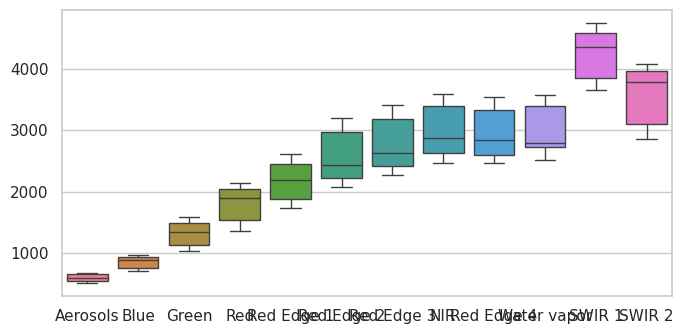

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")
ax = sns.boxplot( data=bands_data)

In [ ]:
fig = plt.gcf()
fig.set_size_inches(18.5, 10.5)

<Figure size 1850x1050 with 0 Axes>

/tmp/ipykernel_2383/2569300063.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


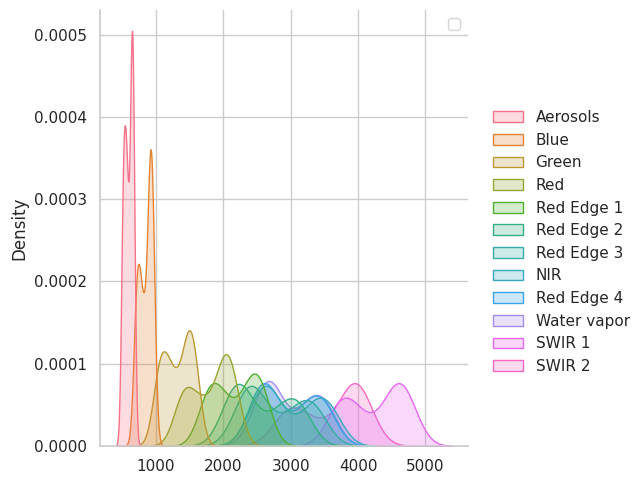

In [ ]:
sns.displot(data=bands_data,kind="kde",fill=True)
plt.legend(loc='upper right')

/tmp/ipykernel_2383/590982475.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


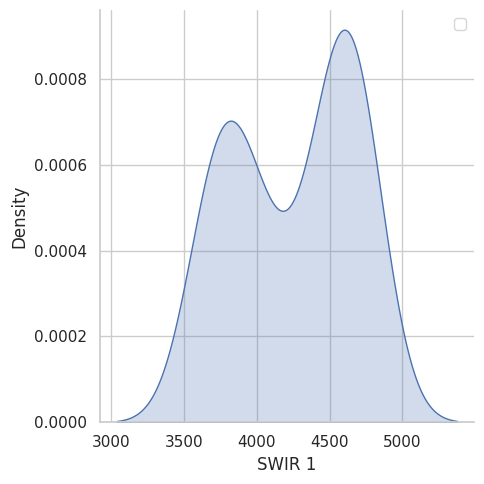

In [ ]:
sns.displot(data=bands_data, x='SWIR 1',kind="kde",fill=True)
plt.legend(loc='upper right')

# Features extractors indexes :
## Normalized Difference Vegetation Index (NDVI)

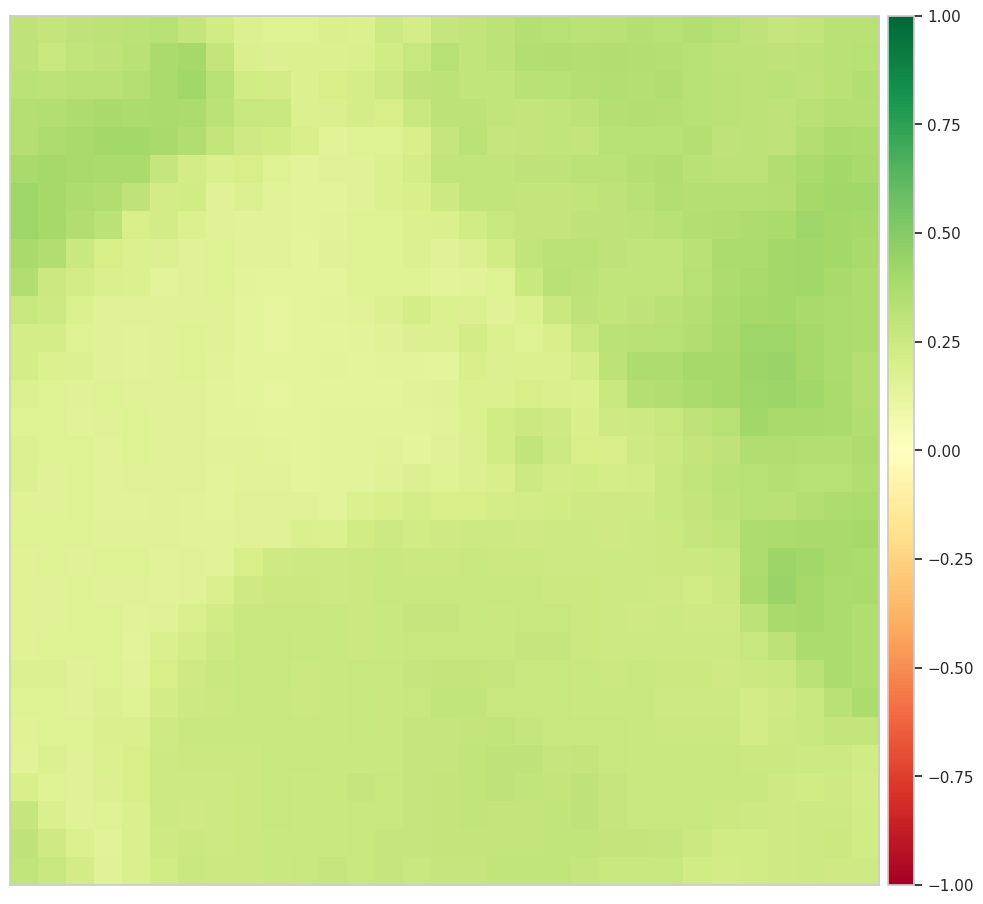

In [ ]:
## Normalized Difference Vegetation Index (NDVI) : Image from March 2017

ndvi = es.normalized_diff(arr_st[7], arr_st[3])

ep.plot_bands(ndvi, cmap="RdYlGn", cols=1, vmin=-1, vmax=1, figsize=(10, 14))

plt.show()

# Soil Adjusted Vegetation Index (SAVI) :

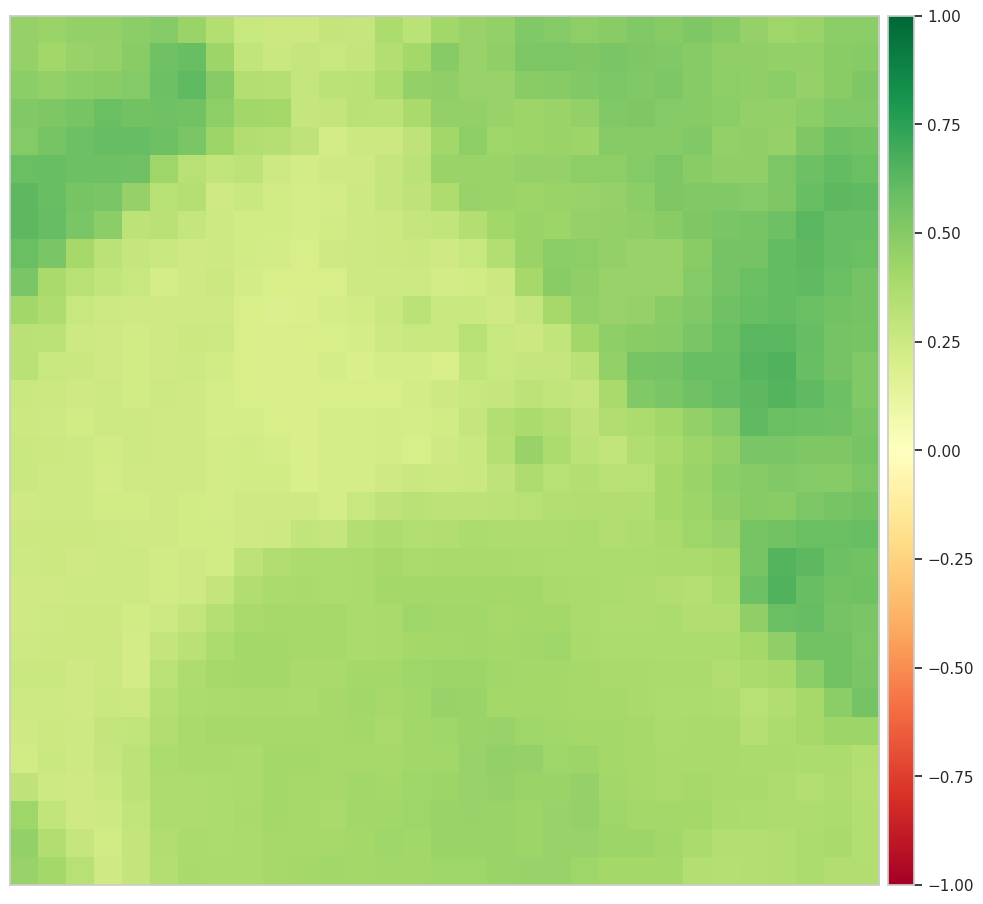

In [ ]:
## Image from March 2019

L = 0.5

savi = ((arr_st[7] - arr_st[3]) / (arr_st[7] + arr_st[3] + L)) * (1 + L)

ep.plot_bands(savi, cmap="RdYlGn", cols=1, vmin=-1, vmax=1, figsize=(10, 14))

plt.show()

# Visible Atmospherically Resistant Index (VARI)

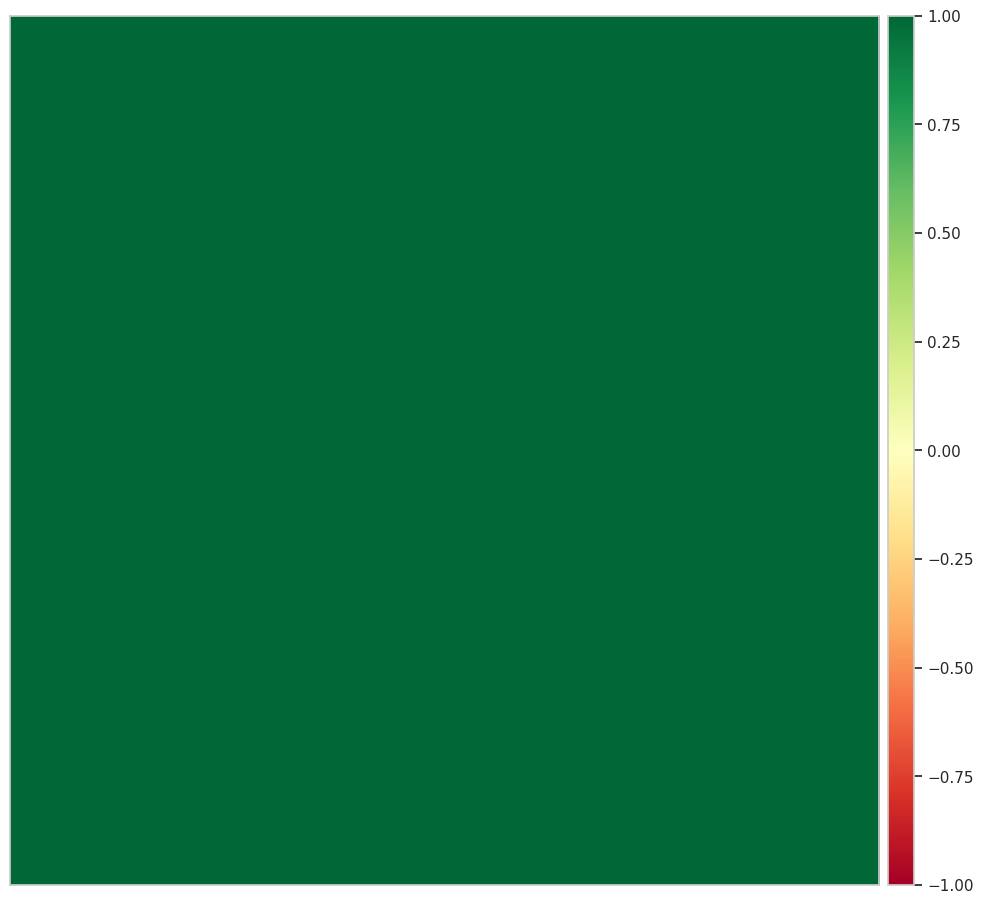

In [ ]:
## Image from March 2017 :


vari = (arr_st[2] - arr_st[3])/ (arr_st[2] + arr_st[3] - arr_st[1])

ep.plot_bands(vari, cmap="RdYlGn", cols=1, vmin=-1, vmax=1, figsize=(10, 14))

plt.show()

# Modified Normalized Difference Water Index (MNDWI) :

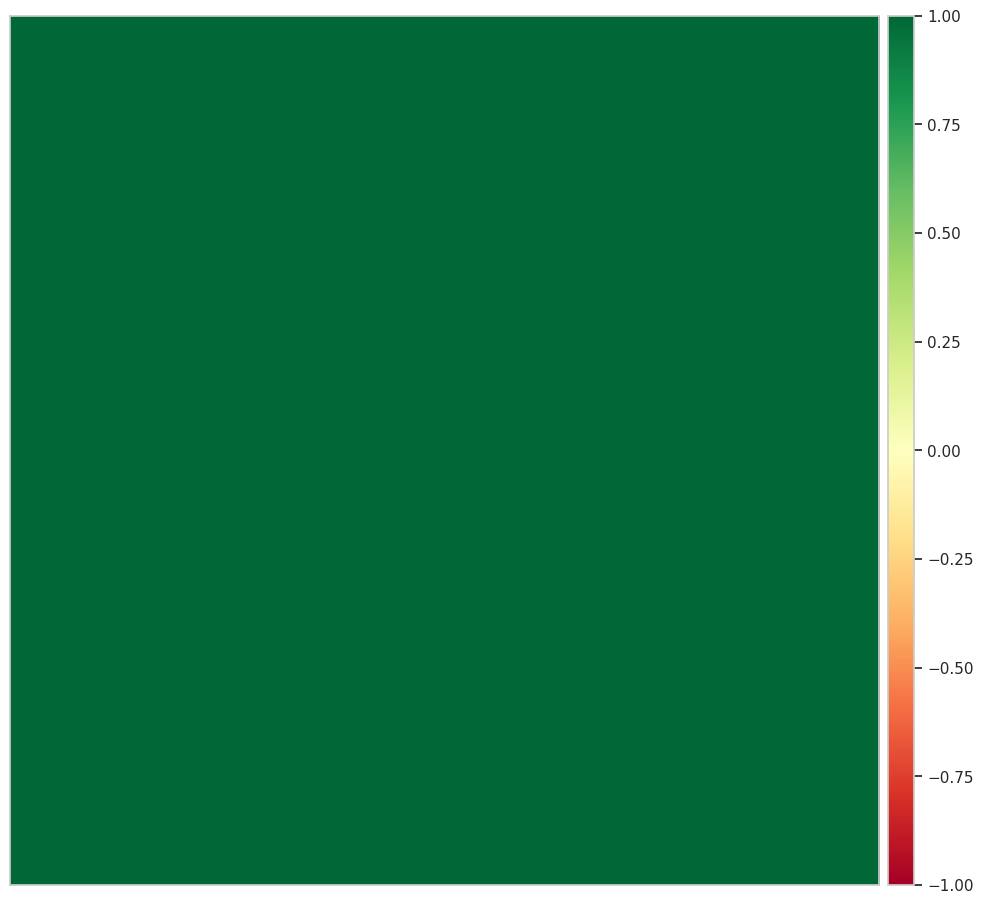

In [ ]:
mndwi = es.normalized_diff(arr_st[2], arr_st[10])

ep.plot_bands(mndwi, cmap="RdYlGn", cols=1, vmin=-1, vmax=1, figsize=(10, 14))

plt.show()

# Normalized Difference Moisture Index (NDMI) :

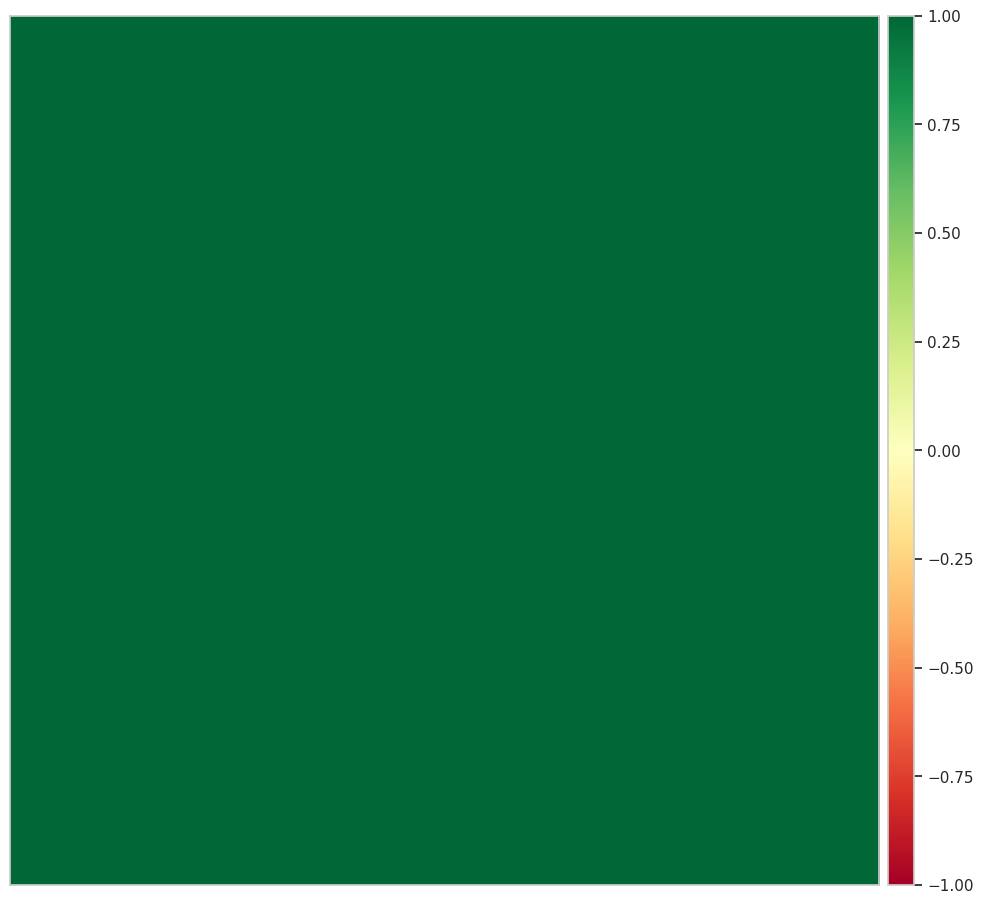

In [ ]:
## Image from March 2019:

ndmi = es.normalized_diff(arr_st[7], arr_st[10])

ep.plot_bands(ndmi, cmap="RdYlGn", cols=1, vmin=-1, vmax=1, figsize=(10, 14))

plt.show()


# Clay minerals

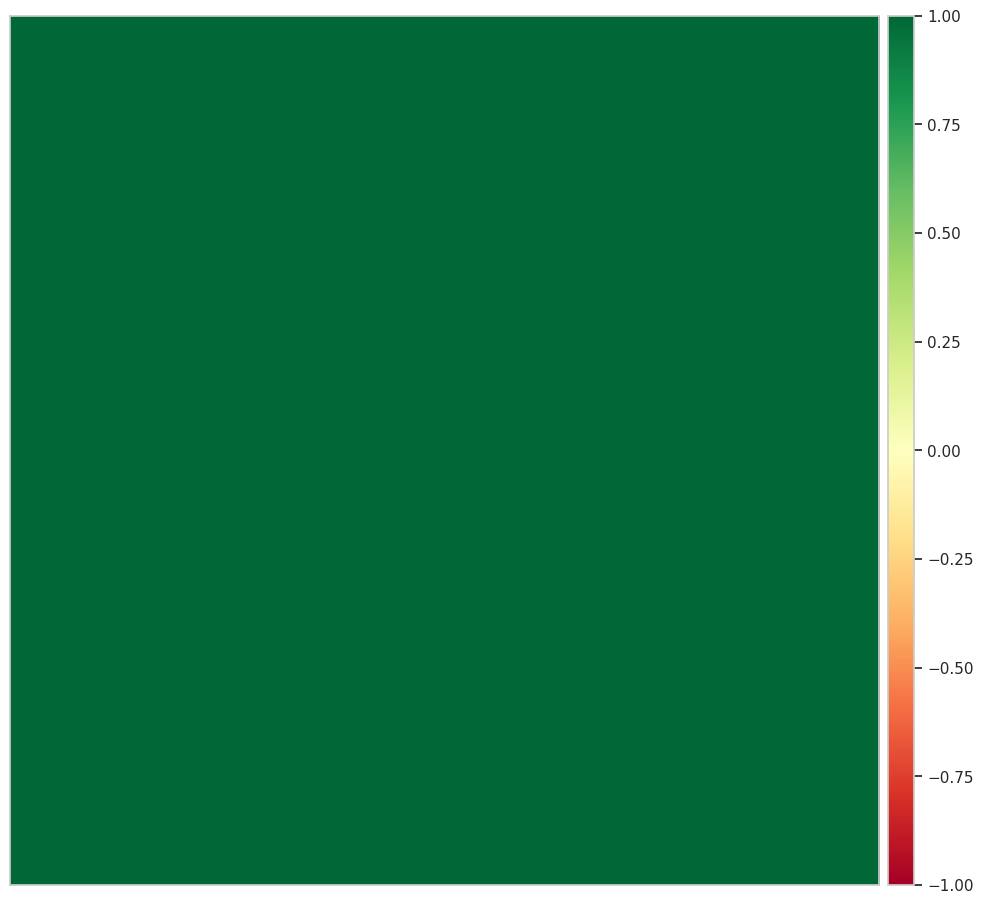

In [ ]:
cmr = np.divide(arr_st[10], arr_st[11])

ep.plot_bands(cmr, cmap="RdYlGn", cols=1, vmin=-1, vmax=1, figsize=(10, 14))

plt.show()

In [ ]:
# Add an new column to dataframe :

def add_indice_to_df(indice,col_name, dataset):
  list_indice=[]
  for i in range (len(indice)):
    list_indice.append(indice[i].mean())
  numpy_array = np.array(list_indice)
  transpose = numpy_array.T
  transpose_list = transpose.tolist()
  if transpose_list[0]> 1 or transpose_list[10]> 1 :
    transpose_list = np.array(transpose_list)
    dataset[col_name]=normalize(transpose_list)
  else :
    dataset[col_name]=transpose_list
  return dataset

In [ ]:

## Normalize bands into 0.0 - 1.0 scale :
def normalize(array):
    array_min, array_max = array.min(), array.max()
    return (array - array_min) / (array_max - array_min)

In [ ]:
bands_data_norm = bands_data.copy()

In [ ]:
## Normalize image bands :

for e in bands_data_norm.columns.values :
  bands_data_norm[e]=normalize (bands_data_norm[e])

In [ ]:
## Add NDVI index to dataframe :

ndvi = es.normalized_diff(arr_st[7], arr_st[3])
bands_data_norm = add_indice_to_df(ndvi,"NDVI",bands_data_norm)
bands_data_norm.head()

,Aerosols,Blue,Green,Red,Red Edge 1,Red Edge 2,Red Edge 3,NIR,Red Edge 4,Water vapor,SWIR 1,SWIR 2,NDVI
0,0.454845,0.424300,0.477551,0.001576,0.411113,1.000000,1.000000,0.999723,0.995295,1.000000,0.293041,0.121003,0.564411
1,0.439063,0.403648,0.465124,0.006797,0.442718,0.991088,0.997681,1.000000,1.000000,0.987890,0.343219,0.157566,0.562059
2,0.424533,0.401978,0.466721,0.040086,0.463819,0.957535,0.963126,0.956964,0.972837,0.967523,0.393633,0.198676,0.547401
3,0.498226,0.464038,0.510023,0.134016,0.504427,0.948335,0.950232,0.937863,0.954299,0.961200,0.464176,0.238754,0.530213
4,0.492923,0.535320,0.575192,0.237437,0.532789,0.931559,0.923295,0.934551,0.929814,0.926139,0.511506,0.283125,0.516263


In [ ]:
import seaborn as sns

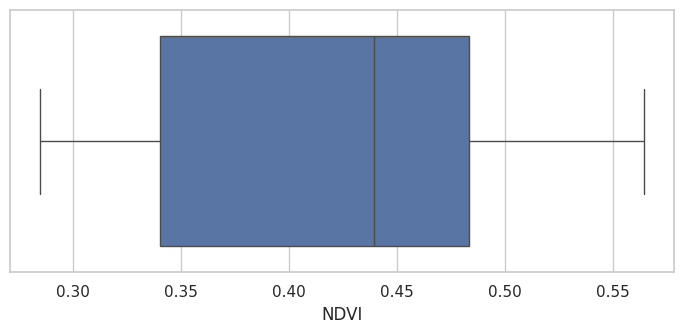

In [ ]:
ax = sns.boxplot( data=bands_data_norm, x='NDVI')

/tmp/ipykernel_1452/942870246.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


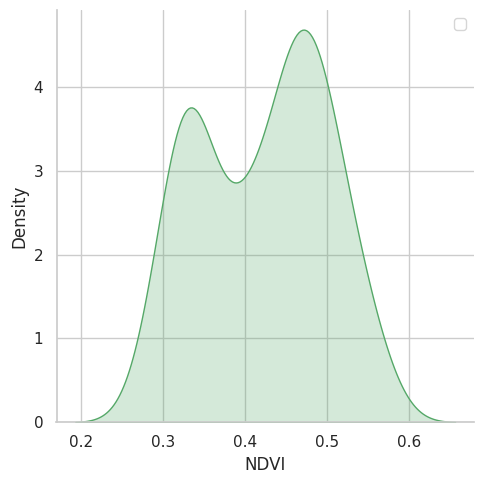

In [ ]:
sns.displot(data=bands_data_norm, x='NDVI',kind="kde",fill=True, color='g')
plt.legend(loc='upper right')

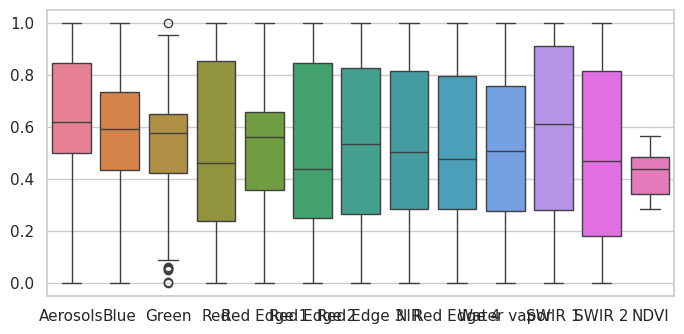

In [ ]:

sns.set_theme(style="whitegrid")
ax = sns.boxplot( data=bands_data_norm)

In [ ]:
## Add NDMI index :

ndmi = es.normalized_diff(arr_st[7], arr_st[10])
bands_data_norm = add_indice_to_df(ndmi,"NDMI",bands_data_norm)
bands_data_norm.head()

,Aerosols,Blue,Green,Red,Red Edge 1,Red Edge 2,Red Edge 3,NIR,Red Edge 4,Water vapor,SWIR 1,SWIR 2,NDVI,NDMI
0,0.454845,0.424300,0.477551,0.001576,0.411113,1.000000,1.000000,0.999723,0.995295,1.000000,0.293041,0.121003,0.564411,0.280373
1,0.439063,0.403648,0.465124,0.006797,0.442718,0.991088,0.997681,1.000000,1.000000,0.987890,0.343219,0.157566,0.562059,0.191994
2,0.424533,0.401978,0.466721,0.040086,0.463819,0.957535,0.963126,0.956964,0.972837,0.967523,0.393633,0.198676,0.547401,0.333770
3,0.498226,0.464038,0.510023,0.134016,0.504427,0.948335,0.950232,0.937863,0.954299,0.961200,0.464176,0.238754,0.530213,0.334710
4,0.492923,0.535320,0.575192,0.237437,0.532789,0.931559,0.923295,0.934551,0.929814,0.926139,0.511506,0.283125,0.516263,0.347093


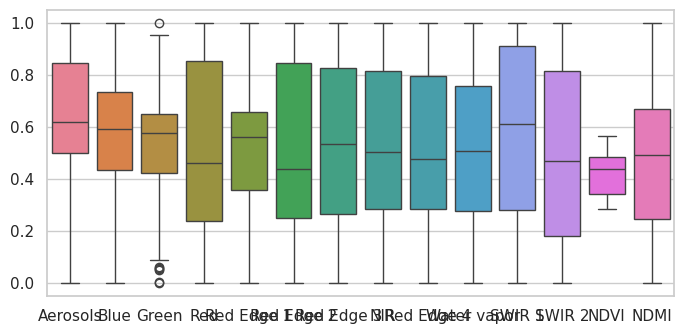

In [ ]:
sns.set_theme(style="whitegrid")
ax = sns.boxplot( data=bands_data_norm)

In [ ]:
## Add SAVI index :

L = 0.5
savi = ((arr_st[7] - arr_st[3]) / (arr_st[7] + arr_st[3] + L)) * (1 + L)
bands_data_norm = add_indice_to_df(savi,"SAVI",bands_data_norm)
bands_data_norm.head()

,Aerosols,Blue,Green,Red,Red Edge 1,Red Edge 2,Red Edge 3,NIR,Red Edge 4,Water vapor,SWIR 1,SWIR 2,NDVI,NDMI,SAVI
0,0.454845,0.424300,0.477551,0.001576,0.411113,1.000000,1.000000,0.999723,0.995295,1.000000,0.293041,0.121003,0.564411,0.280373,0.846534
1,0.439063,0.403648,0.465124,0.006797,0.442718,0.991088,0.997681,1.000000,1.000000,0.987890,0.343219,0.157566,0.562059,0.191994,0.843006
2,0.424533,0.401978,0.466721,0.040086,0.463819,0.957535,0.963126,0.956964,0.972837,0.967523,0.393633,0.198676,0.547401,0.333770,0.821021
3,0.498226,0.464038,0.510023,0.134016,0.504427,0.948335,0.950232,0.937863,0.954299,0.961200,0.464176,0.238754,0.530213,0.334710,0.795243
4,0.492923,0.535320,0.575192,0.237437,0.532789,0.931559,0.923295,0.934551,0.929814,0.926139,0.511506,0.283125,0.516263,0.347093,0.774320


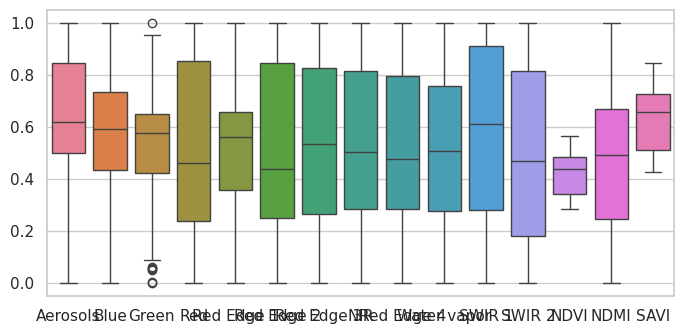

In [ ]:
sns.set_theme(style="whitegrid")
ax = sns.boxplot( data=bands_data_norm)

In [ ]:
ndmi = es.normalized_diff(arr_st[7], arr_st[10])
bands_data_norm = add_indice_to_df(ndmi,"NDMI",bands_data_norm)
bands_data_norm.head()

,Aerosols,Blue,Green,Red,Red Edge 1,Red Edge 2,Red Edge 3,NIR,Red Edge 4,Water vapor,SWIR 1,SWIR 2,NDVI,NDMI,SAVI
0,0.454845,0.424300,0.477551,0.001576,0.411113,1.000000,1.000000,0.999723,0.995295,1.000000,0.293041,0.121003,0.564411,0.280373,0.846534
1,0.439063,0.403648,0.465124,0.006797,0.442718,0.991088,0.997681,1.000000,1.000000,0.987890,0.343219,0.157566,0.562059,0.191994,0.843006
2,0.424533,0.401978,0.466721,0.040086,0.463819,0.957535,0.963126,0.956964,0.972837,0.967523,0.393633,0.198676,0.547401,0.333770,0.821021
3,0.498226,0.464038,0.510023,0.134016,0.504427,0.948335,0.950232,0.937863,0.954299,0.961200,0.464176,0.238754,0.530213,0.334710,0.795243
4,0.492923,0.535320,0.575192,0.237437,0.532789,0.931559,0.923295,0.934551,0.929814,0.926139,0.511506,0.283125,0.516263,0.347093,0.774320


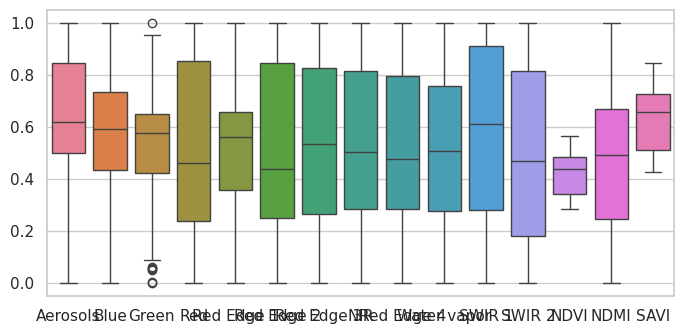

In [ ]:
sns.set_theme(style="whitegrid")
ax = sns.boxplot( data=bands_data_norm)

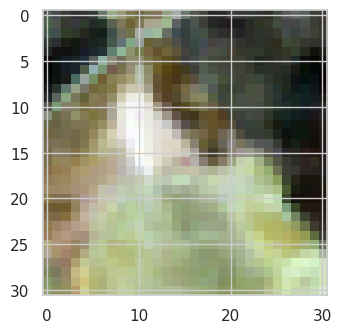

In [ ]:
## visualize specific band combination :

# Open the file:
raster = rasterio.open(S_sentinel_bands[0])

# Normalize bands into 0.0 - 1.0 scale
def normalize(array):
    array_min, array_max = array.min(), array.max()
    return (array - array_min) / (array_max - array_min)

# Convert to numpy arrays
nir = raster.read(4)
red = raster.read(3)
green = raster.read(2)

# Normalize band DN
nir_norm = normalize(nir)
red_norm = normalize(red)
green_norm = normalize(green)

# Stack bands
nrg = np.dstack((nir_norm, red_norm, green_norm))

# View the color composite
plt.imshow(nrg)


In [ ]:
## Open image as array with GDAL :

directory = '/content/drive/MyDrive/test'
data_list =[]
for filename in os.listdir(directory):
    if filename.endswith(".tif"):
      src_ds = gdal.Open( "/content/drive/MyDrive/test/" +str(filename))
      data=src_ds.ReadAsArray()
      data_list.append(data)
      print(filename)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/test'

In [ ]:
# raster file and reads a band of the raster into a numpy array

filepath = S_sentinel_bands[0]

# Open the file:
raster = gdal.Open(filepath)

# Check type of the variable 'raster'
type(raster)

#img_array = ds.ReadAsArray()

osgeo.gdal.Dataset

In [ ]:

# Projection
raster.GetProjection()

# Dimensions
print(raster.RasterXSize)
print(raster.RasterYSize)

# Number of bands
print(raster.RasterCount)

# Metadata for the raster dataset
raster.GetMetadata()


103
104
12


{'AREA_OR_POINT': 'Area'}

In [ ]:
# Read the raster band as separate variable
band = raster.GetRasterBand(1)

# Check type of the variable 'band'
type(band)

# Data type of the values
gdal.GetDataTypeName(band.DataType)

'UInt16'

In [ ]:
# Compute statistics if needed
if band.GetMinimum() is None or band.GetMaximum()is None:
    band.ComputeStatistics(0)
    print("Statistics computed.")

# Fetch metadata for the band
band.GetMetadata()

# Print only selected metadata:
print ("[ NO DATA VALUE ] = ", band.GetNoDataValue()) # none
print ("[ MIN ] = ", band.GetMinimum())
print ("[ MAX ] = ", band.GetMaximum())

[ NO DATA VALUE ] =  None
[ MIN ] =  202.0
[ MAX ] =  1228.0


In [ ]:
## Read Image as Array :

data=raster.ReadAsArray()

In [ ]:

## Visualize :
type(data)
data.shape

(12, 104, 103)

In [ ]:
## variance & mean :
np.var(data), np.mean(data)

(np.float64(1639019.8857638598), np.float64(2334.0042942494397))

In [ ]:
## After normalize bands  :

data_norm = normalize(data)
np.var(data_norm), np.std(data_norm)

(np.float64(0.05741348038025337), np.float64(0.2396111023726851))

# correlation soil moisture Vs images :

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from pylab import rcParams
rcParams['figure.figsize'] = 7,7
import seaborn as sns
import numpy as np
sns.set(color_codes=True, font_scale=1.2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['figure.figsize'] = (7, 7)
sns.set(color_codes=True, font_scale=1.2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [ ]:
!pip install heatmapz

In [ ]:

# Import the two methods from heatmap library
from heatmap import heatmap, corrplot

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area3.csv")

In [ ]:
## Create a dataset of images bands means :

import os
List_images = []
L = 0.5
directory = r'/content/drive/MyDrive/Senti_Images-2017to2021_Area3'
for filename in os.listdir(directory):
    if filename.endswith("QF.tif") :
        image = tif_to_matrix(os.path.join(directory, filename))
        list_bands=[]
        for i in range (12) :
          band = normalize(image[i])
          list_bands.append(band.mean())
        List_images.append(list_bands)

List_images = np.array(List_images)

In [ ]:
df_bands = pd.DataFrame(List_images,columns=['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B10','B11'])

In [ ]:
df_bands['soil_moisture'] = df["soil_moisture_depth_0.050000"]

In [ ]:
## Correlatiion Matrix :

df_bands.corr()

,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B10,B11,soil_moisture
B1,1.000000,0.786273,0.783529,0.793066,0.777391,0.335202,0.284661,0.379220,0.263316,0.337257,0.645503,0.629345,-0.072931
B2,0.786273,1.000000,0.965677,0.851227,0.830692,0.482185,0.446683,0.481848,0.420135,0.431741,0.473513,0.536656,0.073309
B3,0.783529,0.965677,1.000000,0.897846,0.895150,0.575857,0.540733,0.582482,0.508351,0.483835,0.568344,0.598052,0.070611
B4,0.793066,0.851227,0.897846,1.000000,0.960490,0.384932,0.369298,0.454140,0.359123,0.351962,0.778284,0.765783,-0.161200
B5,0.777391,0.830692,0.895150,0.960490,1.000000,0.515919,0.484133,0.560157,0.476577,0.433624,0.767114,0.731065,-0.141971
B6,0.335202,0.482185,0.575857,0.384932,0.515919,1.000000,0.936902,0.910651,0.911208,0.740750,0.286454,0.247502,0.123795
B7,0.284661,0.446683,0.540733,0.369298,0.484133,0.936902,1.000000,0.946255,0.982397,0.811155,0.290607,0.244599,0.110282
B8,0.379220,0.481848,0.582482,0.454140,0.560157,0.910651,0.946255,1.000000,0.946144,0.803130,0.385271,0.326281,0.018024
B8A,0.263316,0.420135,0.508351,0.359123,0.476577,0.911208,0.982397,0.946144,1.000000,0.811522,0.284702,0.239494,0.077639
B9,0.337257,0.431741,0.483835,0.351962,0.433624,0.740750,0.811155,0.803130,0.811522,1.000000,0.240215,0.184798,0.004758


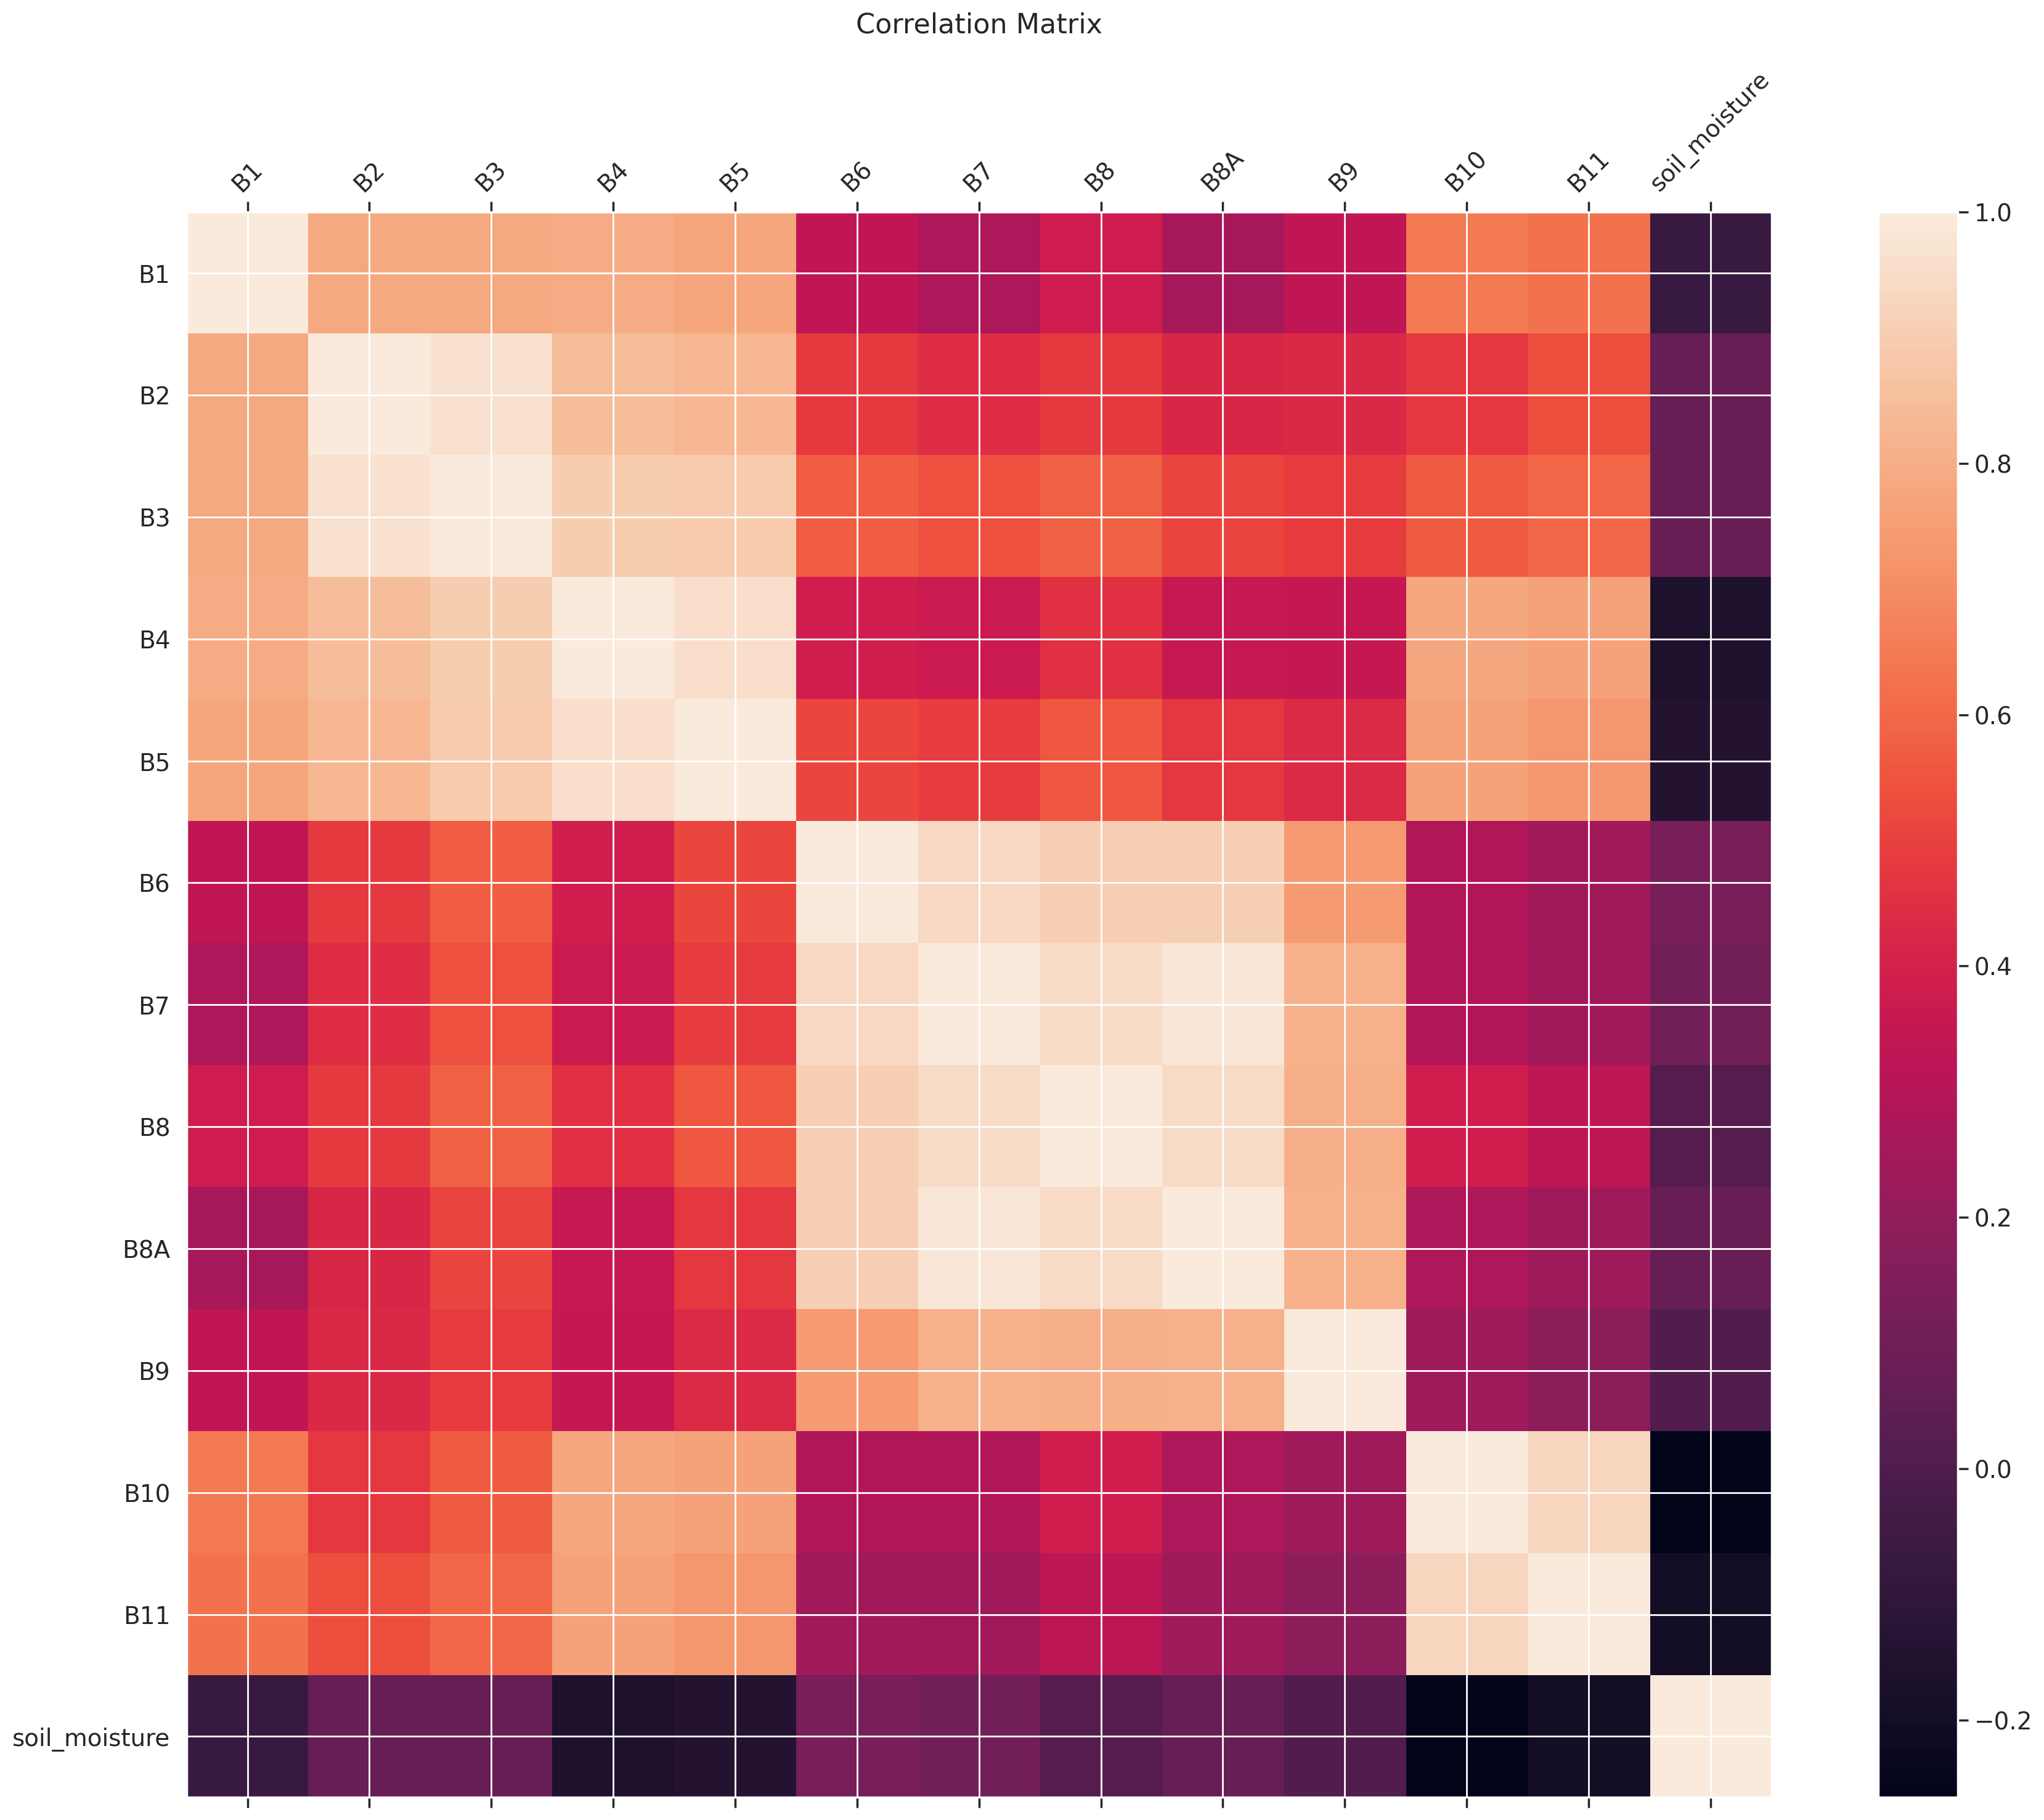

In [ ]:
f, ax = plt.subplots(figsize=(19, 15))

corr = df_bands.corr()
cax = ax.matshow(corr)

cols = df_bands.select_dtypes(['number']).columns
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=14, rotation=45)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=14)

cb = f.colorbar(cax)
cb.ax.tick_params(labelsize=14)

ax.set_title('Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


In [ ]:
import os
List_images = []
L = 0.5
directory = r'/content/drive/MyDrive/Senti_Images-2017to2021_Area3'
for filename in os.listdir(directory):
    if filename.endswith("QF.tif") :
        image = tif_to_matrix(os.path.join(directory, filename))
        list_bands=[]
        for i in range (12) :
          band = normalize(image[i])
          band2 = (band.mean())**2
          list_bands.append(band.mean())
          list_bands.append(band2)
        List_images.append(list_bands)

List_images = np.array(List_images)

In [ ]:
## Check the non-linear correllations :

df_bands = pd.DataFrame(List_images,columns=['B1','B1*2','B2','B2*2','B3','B3*2','B4','B4*2','B5','B5*2','B6','B6*2','B7','B7*2','B8','B8*2','B8A','B8A*2','B9','B9*2','B10','B10*2','B11','B11*2'])

In [ ]:
df_bands['soil_moisture'] = df["soil_moisture_depth_0.050000"]

In [ ]:
df_bands.corr()

,B1,B1*2,B2,B2*2,B3,B3*2,B4,B4*2,B5,B5*2,...,B8*2,B8A,B8A*2,B9,B9*2,B10,B10*2,B11,B11*2,soil_moisture
B1,1.000000,0.982295,0.786273,0.713176,0.783529,0.740294,0.793066,0.780371,0.777391,0.764485,...,0.364055,0.263316,0.241765,0.337257,0.312353,0.645503,0.645666,0.629345,0.631483,-0.072931
B1*2,0.982295,1.000000,0.788430,0.740546,0.792522,0.771278,0.799974,0.807837,0.781512,0.790656,...,0.385788,0.269788,0.258944,0.324332,0.310090,0.631563,0.644557,0.606735,0.620625,-0.076852
B2,0.786273,0.788430,1.000000,0.976597,0.965677,0.959344,0.851227,0.846318,0.830692,0.828459,...,0.482180,0.420135,0.412966,0.431741,0.417276,0.473513,0.470548,0.536656,0.538777,0.073309
B2*2,0.713176,0.740546,0.976597,1.000000,0.933134,0.964253,0.782158,0.800512,0.761109,0.781616,...,0.484769,0.420483,0.428077,0.421899,0.422301,0.356708,0.360341,0.440140,0.451006,0.104331
B3,0.783529,0.792522,0.965677,0.933134,1.000000,0.983287,0.897846,0.893450,0.895150,0.891215,...,0.578126,0.508351,0.494658,0.483835,0.454307,0.568344,0.566930,0.598052,0.600892,0.070611
B3*2,0.740294,0.771278,0.959344,0.964253,0.983287,1.000000,0.855284,0.873488,0.847928,0.867109,...,0.576248,0.498860,0.499807,0.466558,0.451856,0.483193,0.489608,0.530608,0.542767,0.080390
B4,0.793066,0.799974,0.851227,0.782158,0.897846,0.855284,1.000000,0.988485,0.960490,0.951489,...,0.446355,0.359123,0.342398,0.351962,0.320869,0.778284,0.783933,0.765783,0.770760,-0.161200
B4*2,0.780371,0.807837,0.846318,0.800512,0.893450,0.873488,0.988485,1.000000,0.945551,0.959454,...,0.463093,0.364440,0.357481,0.351632,0.330336,0.751718,0.769105,0.736775,0.753157,-0.181719
B5,0.777391,0.781512,0.830692,0.761109,0.895150,0.847928,0.960490,0.945551,1.000000,0.987363,...,0.554328,0.476577,0.463686,0.433624,0.394989,0.767114,0.764820,0.731065,0.730539,-0.141971
B5*2,0.764485,0.790656,0.828459,0.781616,0.891215,0.867109,0.951489,0.959454,0.987363,1.000000,...,0.561980,0.472229,0.471330,0.423093,0.396510,0.739079,0.749715,0.703370,0.715438,-0.163016


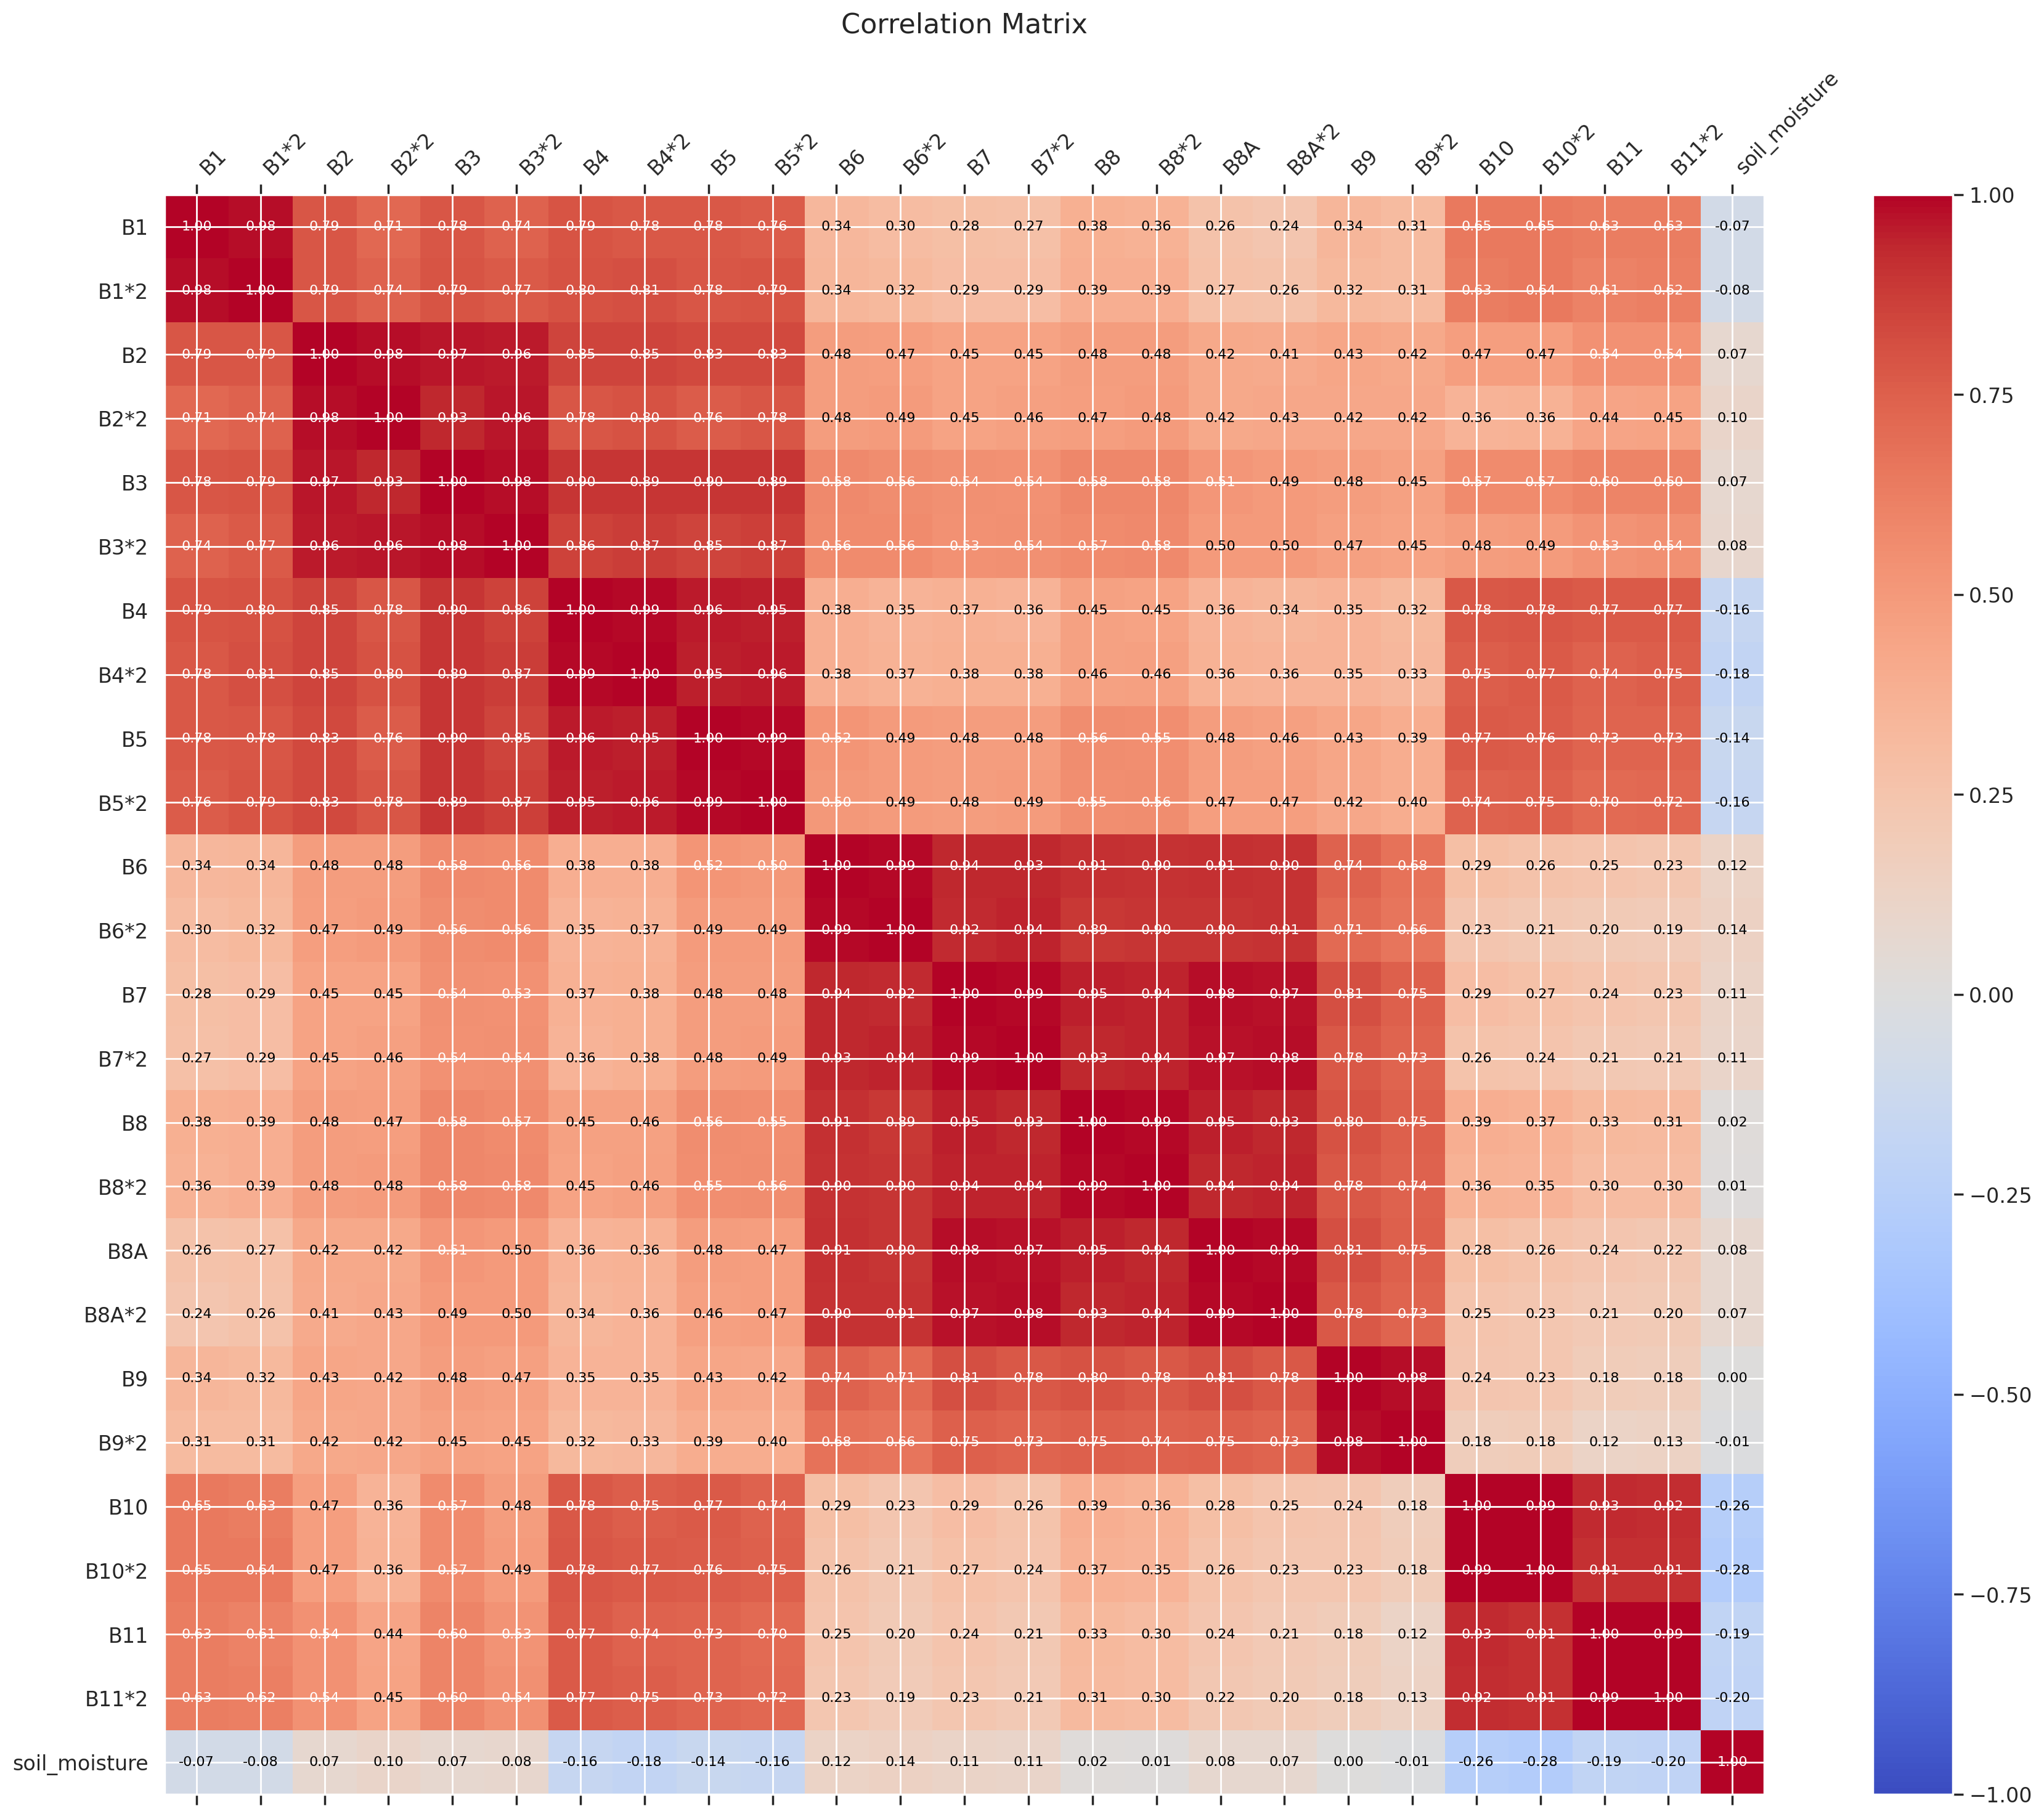

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f, ax = plt.subplots(figsize=(19, 15))

corr = df_bands.corr(numeric_only=True)
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

cols = corr.columns
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=12, rotation=45, ha='left')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=12)

# Add values inside each cell
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.iloc[i, j]
        txt_color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f"{v:.2f}", va='center', ha='center', color=txt_color, fontsize=8)

cb = f.colorbar(cax)
cb.ax.tick_params(labelsize=12)

ax.set_title('Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


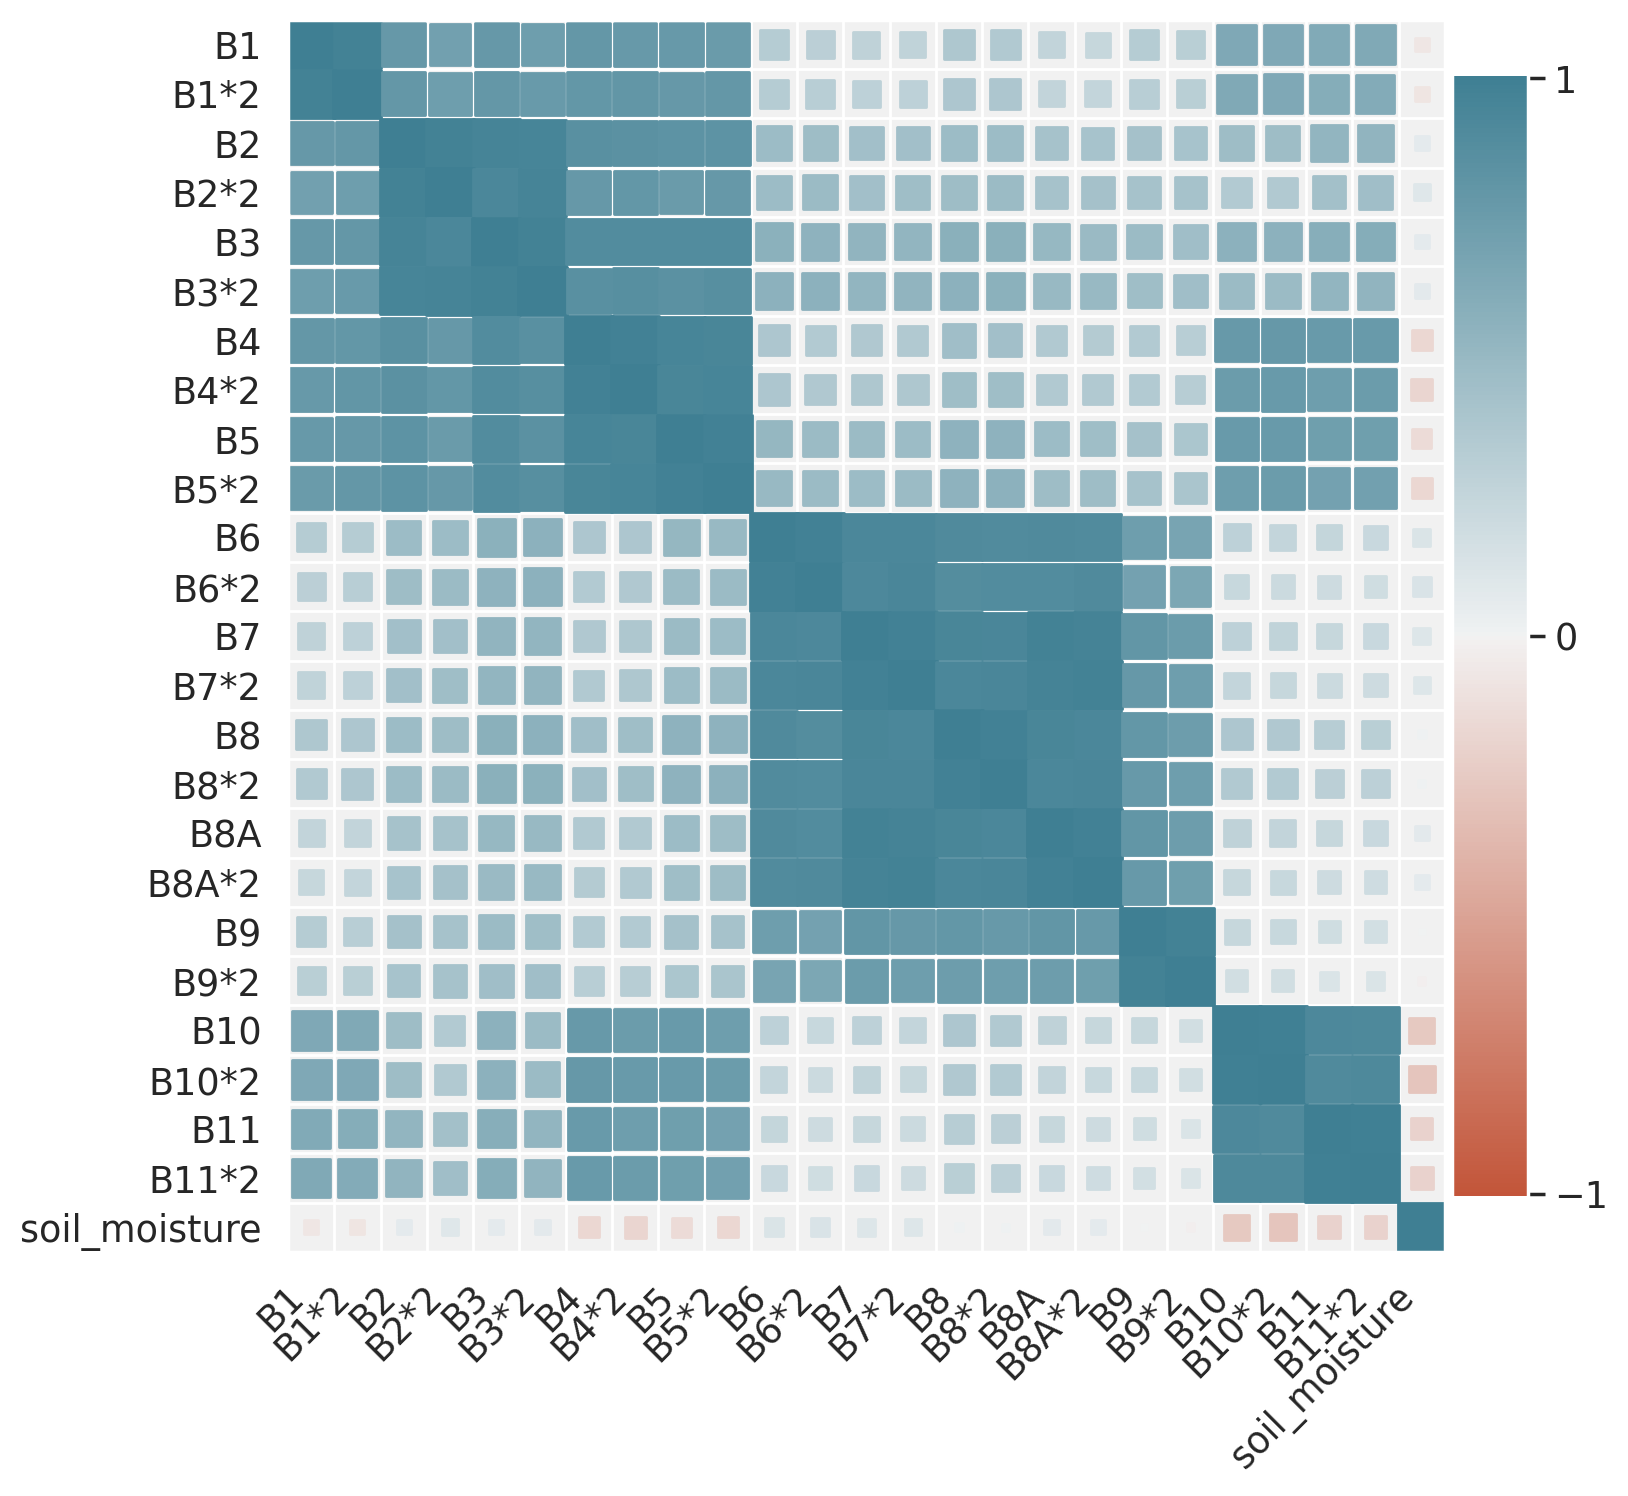

In [ ]:
plt.figure(figsize=(8, 8))
corrplot(df_bands.corr(), size_scale=300);

In [ ]:
import os
List_images = []
L = 0.5
directory = r'/content/drive/MyDrive/Senti_Images-2017to2021_Area3'
for filename in os.listdir(directory):
    if filename.endswith("QF.tif") :
        image = tif_to_matrix(os.path.join(directory, filename))
        list_bands=[]
        for i in range (12) :
          band = normalize(image[i])
          list_bands.append(band.mean())
        ndmi = es.normalized_diff(image[7], image[10])
        ndvi = es.normalized_diff(image[7], image[3])
        savi = ((image[7] - image[3]) / (image[7] + image[3] + L)) * (1 + L)
        mndwi = es.normalized_diff(image[2], image[10])
        list_bands.append(ndmi.mean())
        list_bands.append(ndvi.mean())
        list_bands.append(savi.mean())
        list_bands.append(mndwi.mean())
        List_images.append(list_bands)


In [ ]:
List_images = np.array(List_images)

In [ ]:

List_images.shape

(215, 16)

In [ ]:
df_bands = pd.DataFrame(List_images,columns=['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B10','B11','ndmi','ndvi','savi','mndwi'])

In [ ]:
df_bands['soil_moisture'] = df["soil_moisture_depth_0.050000"]

In [ ]:
df_bands.corr()

,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B10,B11,ndmi,ndvi,savi,mndwi,soil_moisture
B1,1.000000,0.786273,0.783529,0.793066,0.777391,0.335202,0.284661,0.379220,0.263316,0.337257,0.645503,0.629345,-0.129742,-0.043782,-0.043751,-0.444759,-0.072931
B2,0.786273,1.000000,0.965677,0.851227,0.830692,0.482185,0.446683,0.481848,0.420135,0.431741,0.473513,0.536656,-0.272820,0.117496,0.117531,-0.582678,0.073309
B3,0.783529,0.965677,1.000000,0.897846,0.895150,0.575857,0.540733,0.582482,0.508351,0.483835,0.568344,0.598052,-0.267635,0.095598,0.095634,-0.566350,0.070611
B4,0.793066,0.851227,0.897846,1.000000,0.960490,0.384932,0.369298,0.454140,0.359123,0.351962,0.778284,0.765783,-0.119710,-0.050722,-0.050684,-0.563029,-0.161200
B5,0.777391,0.830692,0.895150,0.960490,1.000000,0.515919,0.484133,0.560157,0.476577,0.433624,0.767114,0.731065,-0.205931,-0.022336,-0.022298,-0.552186,-0.141971
B6,0.335202,0.482185,0.575857,0.384932,0.515919,1.000000,0.936902,0.910651,0.911208,0.740750,0.286454,0.247502,-0.499029,0.201687,0.201708,-0.385663,0.123795
B7,0.284661,0.446683,0.540733,0.369298,0.484133,0.936902,1.000000,0.946255,0.982397,0.811155,0.290607,0.244599,-0.430507,0.172071,0.172089,-0.356872,0.110282
B8,0.379220,0.481848,0.582482,0.454140,0.560157,0.910651,0.946255,1.000000,0.946144,0.803130,0.385271,0.326281,-0.429058,0.142976,0.142999,-0.405557,0.018024
B8A,0.263316,0.420135,0.508351,0.359123,0.476577,0.911208,0.982397,0.946144,1.000000,0.811522,0.284702,0.239494,-0.433977,0.166994,0.167012,-0.357642,0.077639
B9,0.337257,0.431741,0.483835,0.351962,0.433624,0.740750,0.811155,0.803130,0.811522,1.000000,0.240215,0.184798,-0.373000,0.078182,0.078203,-0.347889,0.004758


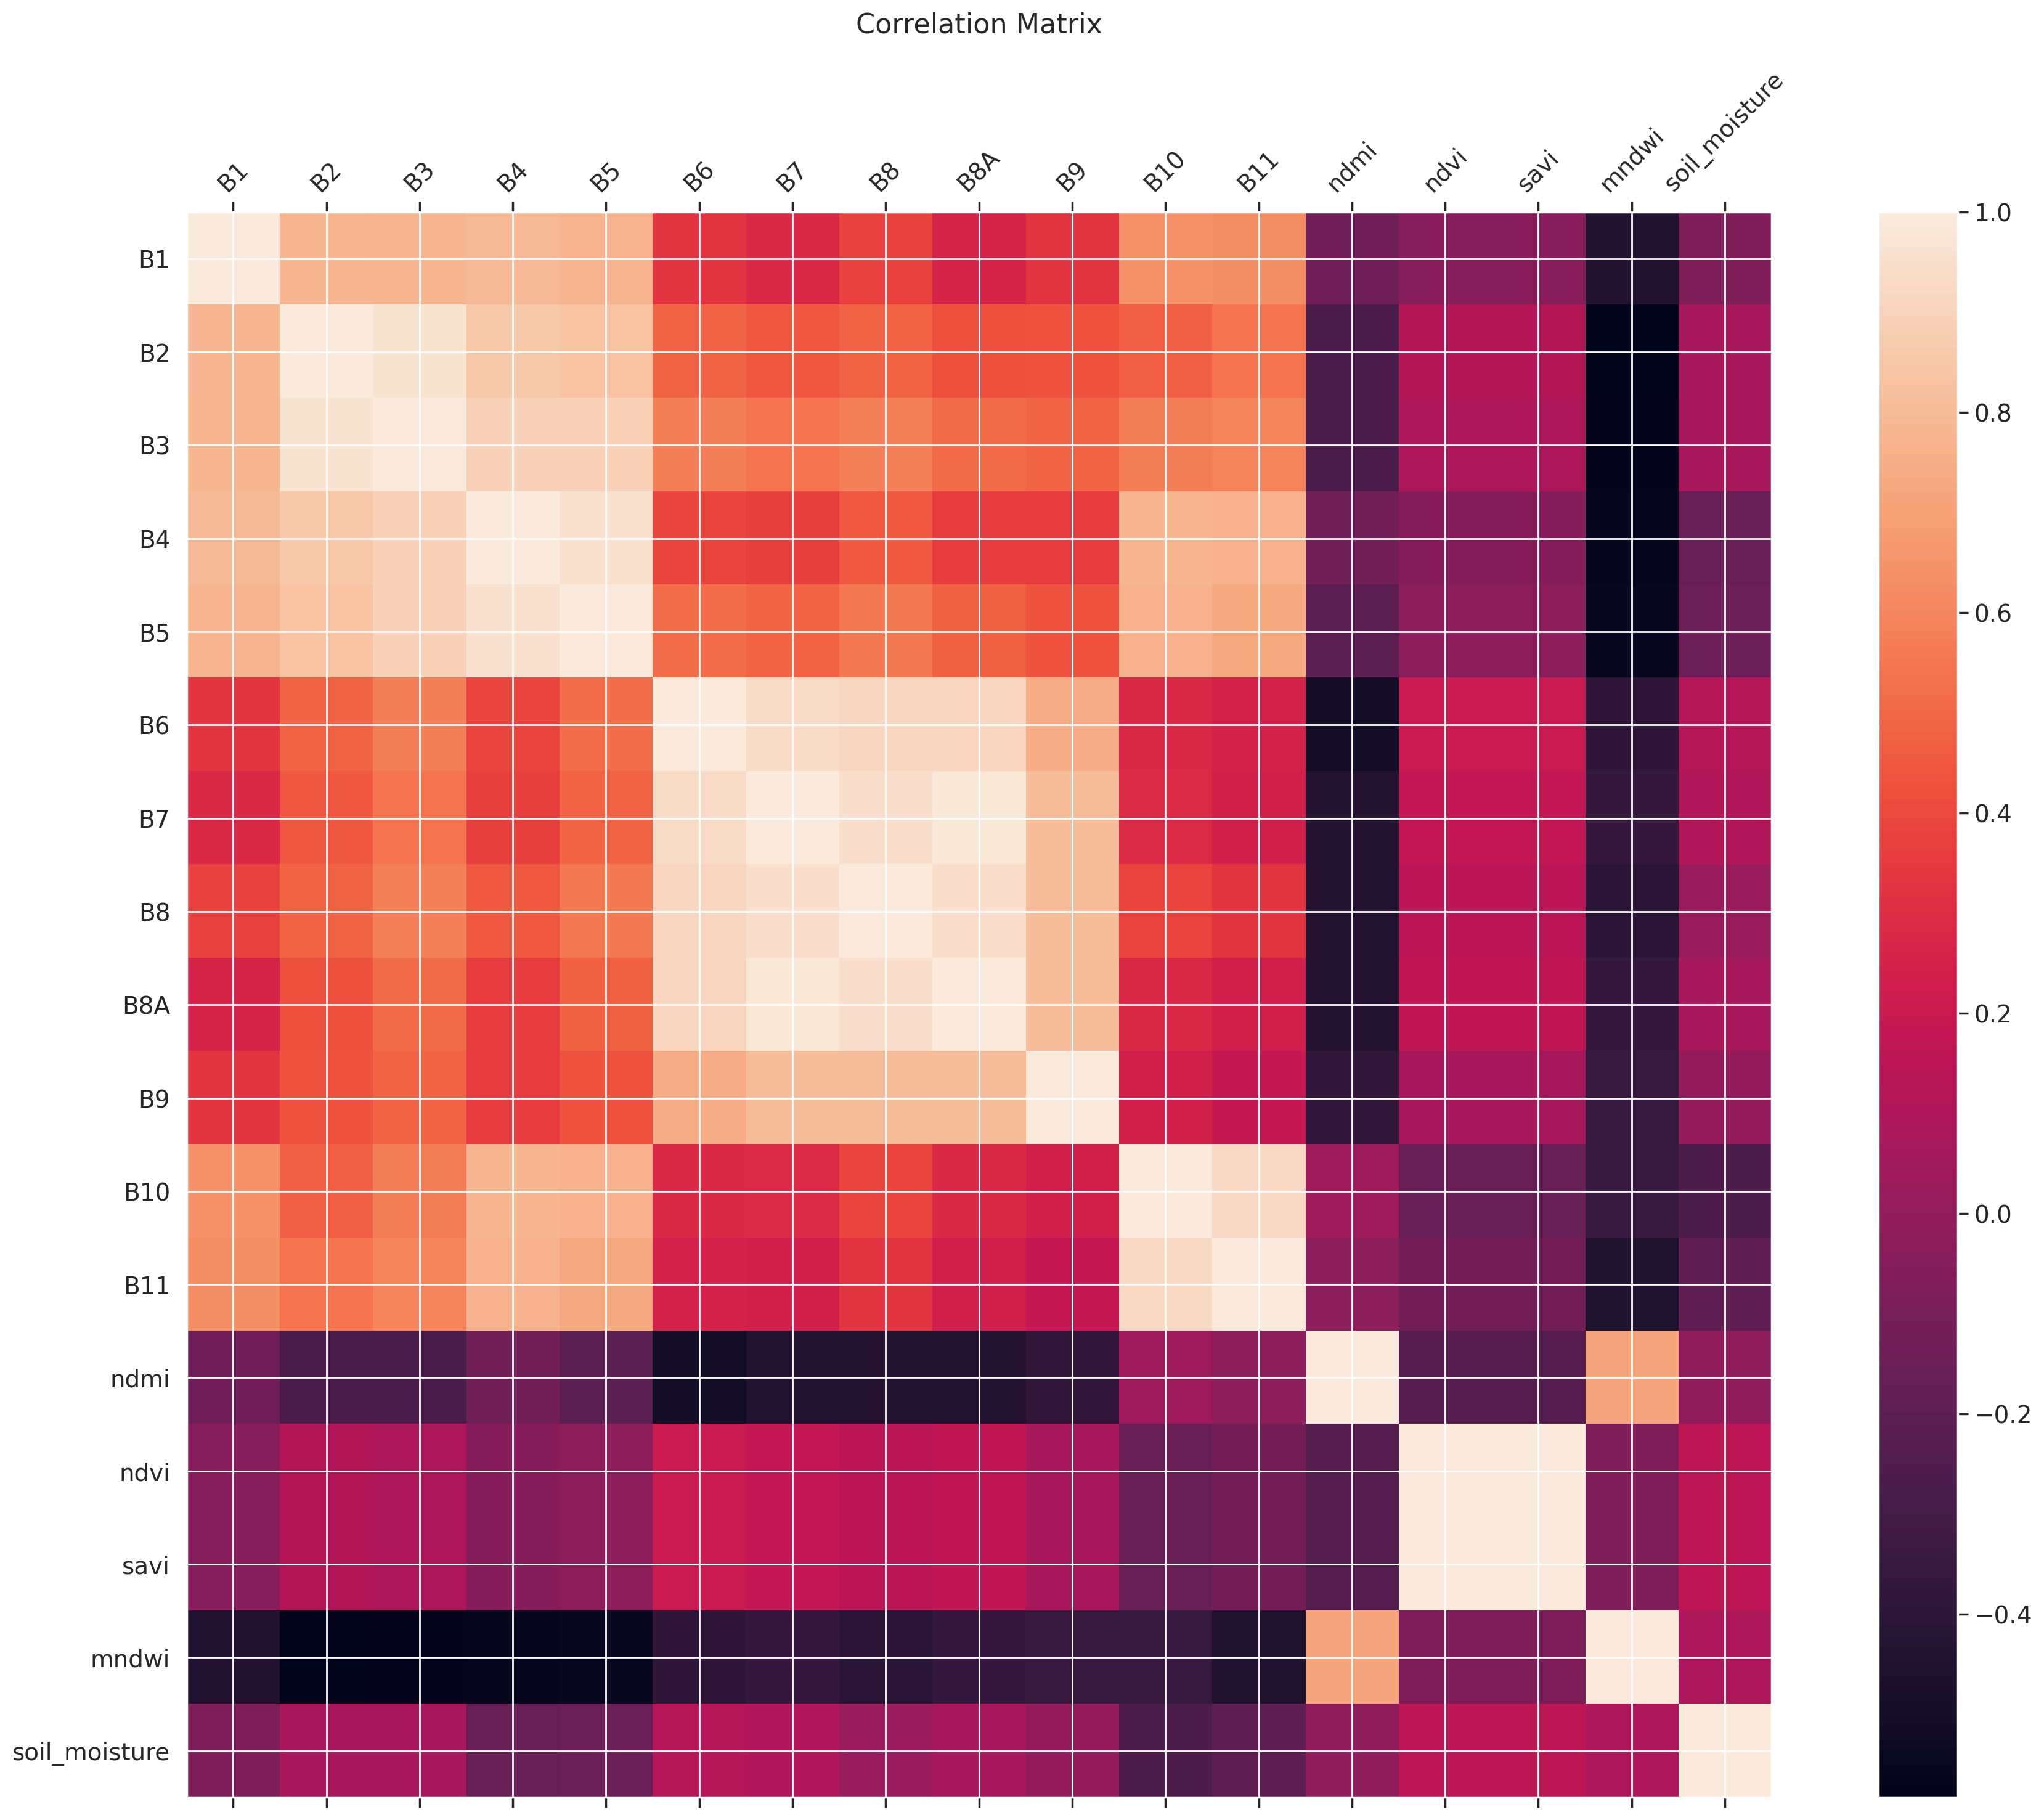

In [ ]:
f, ax = plt.subplots(figsize=(19, 15))

corr = df_bands.corr()
cax = ax.matshow(corr)

cols = df_bands.select_dtypes(['number']).columns
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=14, rotation=45)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=14)

cb = f.colorbar(cax)
cb.ax.tick_params(labelsize=14)

ax.set_title('Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

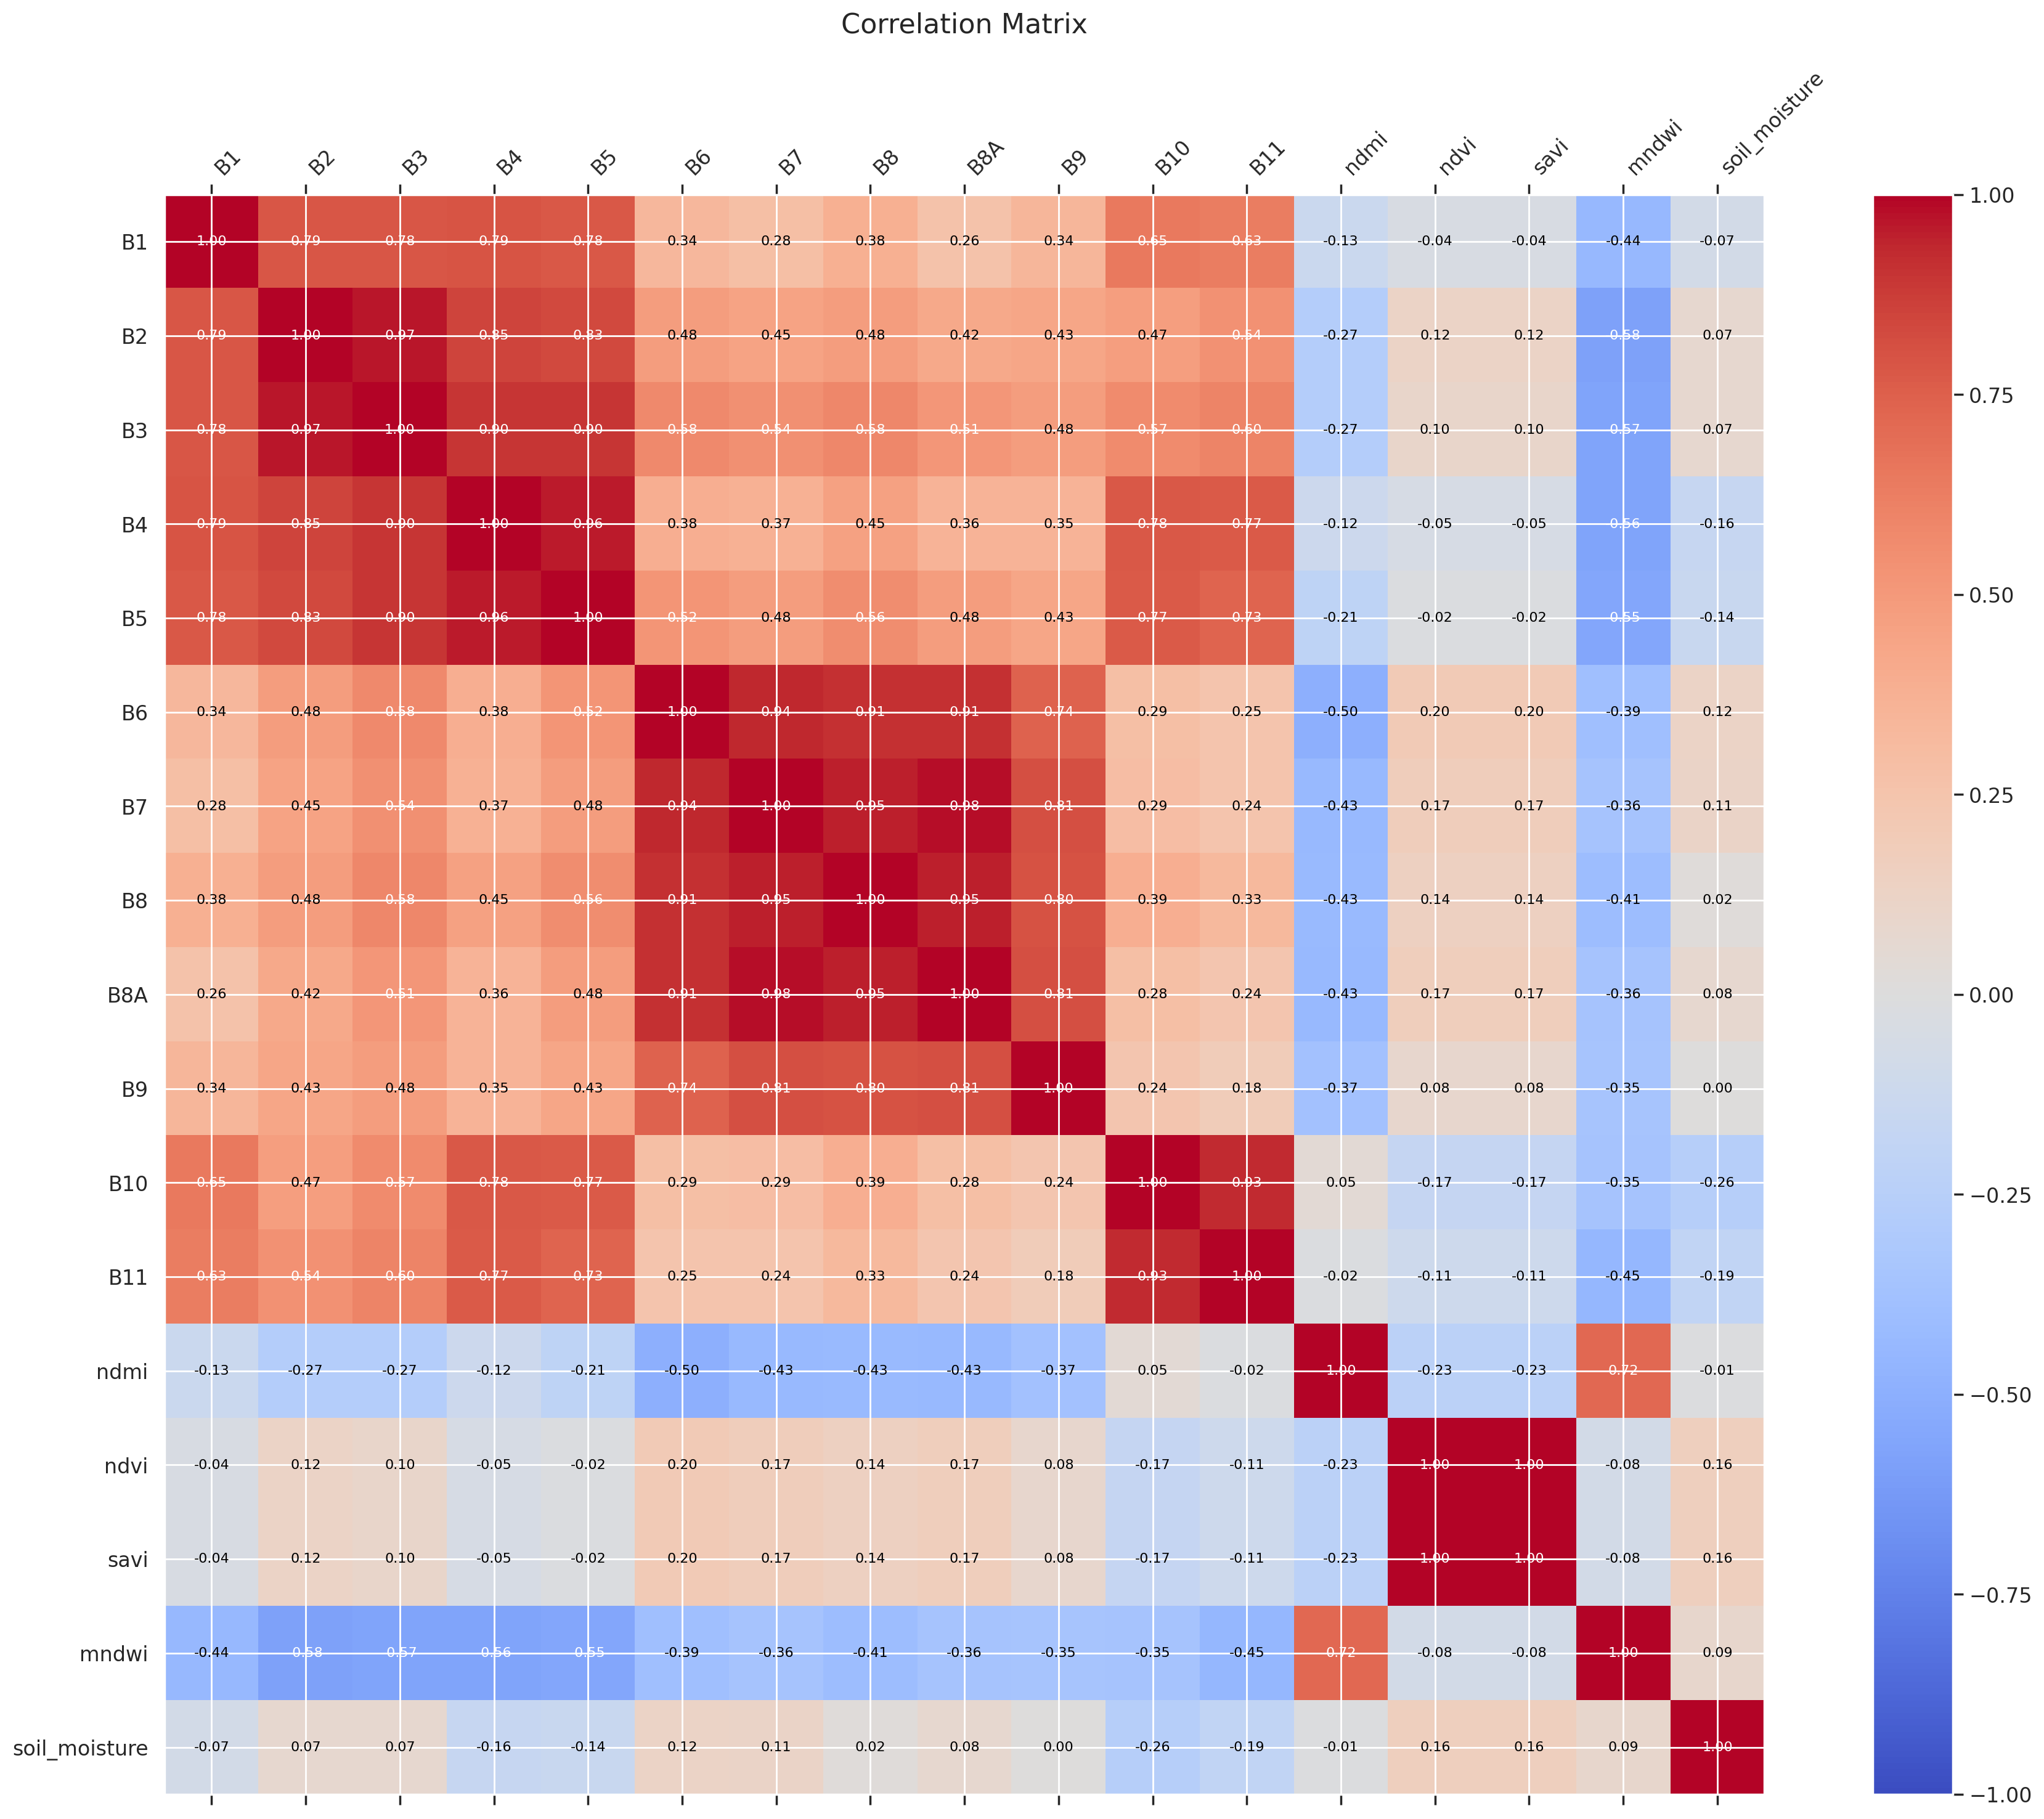

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f, ax = plt.subplots(figsize=(19, 15))

corr = df_bands.corr(numeric_only=True)
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

cols = corr.columns
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=12, rotation=45, ha='left')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=12)

# Add values inside each cell
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.iloc[i, j]
        txt_color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f"{v:.2f}", va='center', ha='center', color=txt_color, fontsize=8)

cb = f.colorbar(cax)
cb.ax.tick_params(labelsize=12)

ax.set_title('Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


In [ ]:
import os
List_images = []
L = 0.5
directory = r'/content/drive/MyDrive/Senti_Images-2017to2021_Area3'
for filename in os.listdir(directory):
    if filename.endswith("QF.tif") :
        image = tif_to_matrix(os.path.join(directory, filename))
        list_bands=[]
        band1 = normalize(image[0])
        band5 = normalize(image[4])
        band9 = normalize(image[9])
        cul1 = normalize((image[1]+image[2]+image[3])/3)
        cul2 = normalize((image[5]+image[6]+image[7]+image[8])/4)
        cul3 = normalize((image[10]+image[11])/2)
        list_bands.append(band1.mean())
        list_bands.append(cul1.mean())
        list_bands.append(band5.mean())
        list_bands.append(cul2.mean())
        list_bands.append(band9.mean())
        list_bands.append(cul3.mean())
        ndmi = es.normalized_diff(image[7], image[10])
        ndvi = es.normalized_diff(image[7], image[3])
        savi = ((image[7] - image[3]) / (image[7] + image[3] + L)) * (1 + L)
        mndwi = es.normalized_diff(image[2], image[10])
        list_bands.append(ndmi.mean())
        list_bands.append(ndvi.mean())
        list_bands.append(savi.mean())
        list_bands.append(mndwi.mean())
        List_images.append(list_bands)

In [ ]:
df_bands = pd.DataFrame(List_images,columns=['B1','B2+3+4','B5','B6+7+8+8A','B9','B10+11','ndmi','ndvi','savi','mndwi'])

In [ ]:
df_bands.corr()

,B1,B2+3+4,B5,B6+7+8+8A,B9,B10+11,ndmi,ndvi,savi,mndwi,soil_moisture
B1,1.000000,0.808118,0.777391,0.304378,0.337257,0.643174,-0.129742,-0.043782,-0.043751,-0.444759,-0.072931
B2+3+4,0.808118,1.000000,0.928346,0.472176,0.434533,0.664250,-0.209161,0.035877,0.035914,-0.576597,-0.020561
B5,0.777391,0.928346,1.000000,0.497750,0.433624,0.762673,-0.205931,-0.022336,-0.022298,-0.552186,-0.141971
B6+7+8+8A,0.304378,0.472176,0.497750,1.000000,0.799451,0.293550,-0.450048,0.180145,0.180164,-0.367229,0.103654
B9,0.337257,0.434533,0.433624,0.799451,1.000000,0.230794,-0.373000,0.078182,0.078203,-0.347889,0.004758
B10+11,0.643174,0.664250,0.762673,0.293550,0.230794,1.000000,0.007463,-0.143342,-0.143313,-0.400920,-0.236181
ndmi,-0.129742,-0.209161,-0.205931,-0.450048,-0.373000,0.007463,1.000000,-0.228621,-0.228667,0.717910,-0.011560
ndvi,-0.043782,0.035877,-0.022336,0.180145,0.078182,-0.143342,-0.228621,1.000000,1.000000,-0.076653,0.156977
savi,-0.043751,0.035914,-0.022298,0.180164,0.078203,-0.143313,-0.228667,1.000000,1.000000,-0.076718,0.156972
mndwi,-0.444759,-0.576597,-0.552186,-0.367229,-0.347889,-0.400920,0.717910,-0.076653,-0.076718,1.000000,0.092267


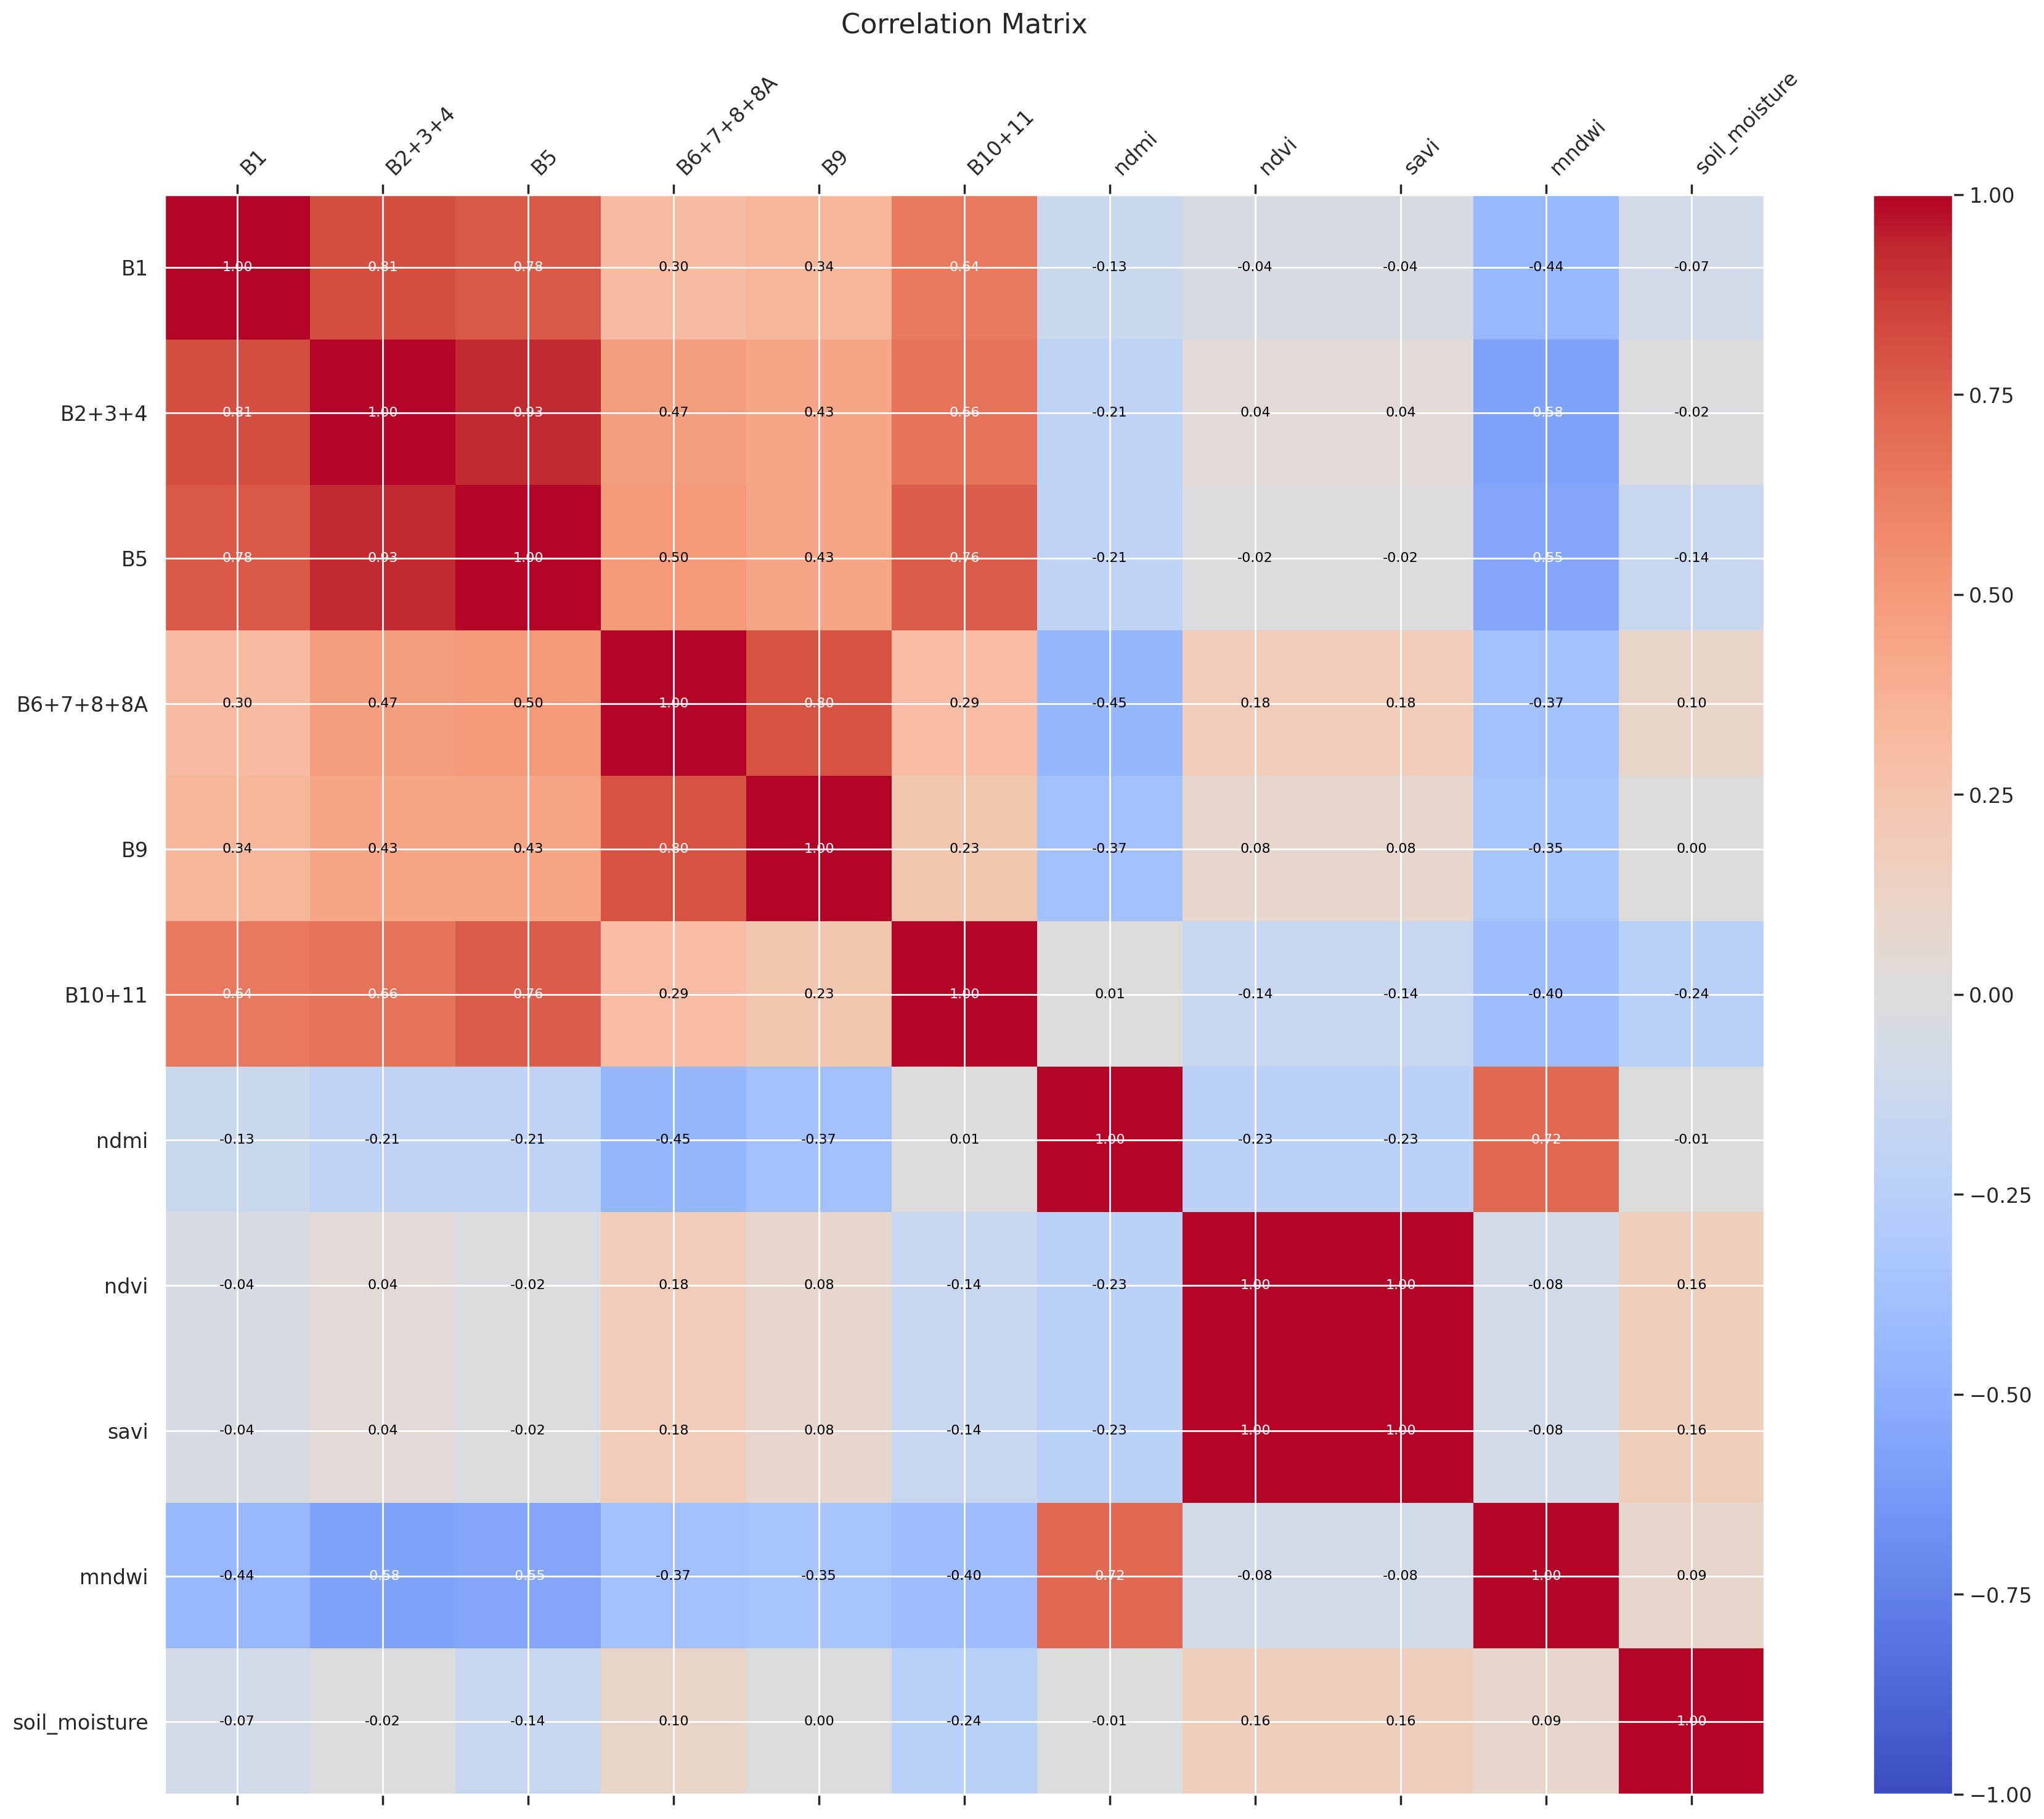

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f, ax = plt.subplots(figsize=(19, 15))

corr = df_bands.corr(numeric_only=True)
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

cols = corr.columns
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=12, rotation=45, ha='left')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=12)

# Add values inside each cell
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.iloc[i, j]
        txt_color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f"{v:.2f}", va='center', ha='center', color=txt_color, fontsize=8)

cb = f.colorbar(cax)
cb.ax.tick_params(labelsize=12)

ax.set_title('Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

# === CONFIGURE THESE ===
area_dirs = {
    'Area1': '/content/drive/MyDrive/Senti_Images-2017to2021_Area1',
    'Area2': '/content/drive/MyDrive/Senti_Images-2017to2021_Area2',
    'Area3': '/content/drive/MyDrive/Senti_Images-2017to2021_Area1imageviz/Area3',
}
output_dir = '/content/drive/MyDrive/imageviz/All_Areas_TIF'
# ========================

os.makedirs(output_dir, exist_ok=True)

count = 0
skipped = 0

for area_name, area_path in area_dirs.items():
    if not os.path.exists(area_path):
        print(f"⚠️ {area_path} does not exist — skipping")
        continue

    tifs = [f for f in os.listdir(area_path) if f.lower().endswith('.tif')]
    print(f"\n📁 {area_name}: found {len(tifs)} TIF files")

    for fname in sorted(tifs):
        # Original:  20230115_B4.tif
        # New:       Area1_20230115_B4.tif
        new_name = f"{area_name}_{fname}"
        src = os.path.join(area_path, fname)
        dst = os.path.join(output_dir, new_name)

        if os.path.exists(dst):
            print(f"  ⚠️ Already exists, skipping: {new_name}")
            skipped += 1
            continue

        shutil.copy2(src, dst)
        count += 1

print(f"\n✅ Done! Copied {count} files to {output_dir}")
if skipped:
    print(f"⚠️ Skipped {skipped} duplicates")

# Verify
all_files = os.listdir(output_dir)
print(f"\n📂 Total files in output: {len(all_files)}")
print("Sample files:")
for f in sorted(all_files)[:10]:
    print(f"  {f}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from pathlib import Path

# If running in Colab and Drive is not mounted yet, uncomment:
#from google.colab import drive
#drive.mount('/content/drive')

# Source folders: key = prefix to add in output filename
area_dirs = {
    "Area1": "/content/drive/MyDrive/Senti_Images-2017to2021_Area1",
    "Area2": "/content/drive/MyDrive/Senti_Images-2017to2021_Area2",
    "Area3": "/content/drive/MyDrive/Senti_Images-2017to2021_Area3",
    "Area5": "/content/drive/MyDrive/Senti_Images-2017to2024_Area5",
    "Area6": "/content/drive/MyDrive/Senti_Images-2017to2024_Area6",
}

output_dir = Path("/content/drive/MyDrive/imageviznew(area 1,2,3,5,6)/All_Areas_tif")
output_dir.mkdir(parents=True, exist_ok=True)

copied = 0
skipped = 0
missing_folders = 0

print(f"Output folder: {output_dir}\n")

for area_name, area_path in area_dirs.items():
    src_dir = Path(area_path)

    if not src_dir.exists():
        print(f"⚠️ Missing folder, skipping: {src_dir}")
        missing_folders += 1
        continue

    # Non-recursive scan (files directly inside folder)
    tif_files = sorted(
        f for f in src_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".tif", ".tiff"]
    )

    print(f"📁 {area_name}: found {len(tif_files)} tif/tiff files")

    area_copied = 0
    area_skipped = 0

    for src_file in tif_files:
        new_name = f"{area_name}_{src_file.name}"
        dst_file = output_dir / new_name

        if dst_file.exists():
            area_skipped += 1
            skipped += 1
            continue

        shutil.copy2(src_file, dst_file)
        area_copied += 1
        copied += 1

    print(f"   ✅ copied: {area_copied}, ⚠️ skipped(existing): {area_skipped}")

all_files = sorted(f.name for f in output_dir.iterdir() if f.is_file())
print("\n================ SUMMARY ================")
print(f"✅ Total newly copied: {copied}")
print(f"⚠️ Total skipped duplicates: {skipped}")
print(f"⚠️ Missing source folders: {missing_folders}")
print(f"📂 Total files now in output: {len(all_files)}")
print("Sample files:")
for f in all_files[:15]:
    print(" ", f)


Output folder: /content/drive/MyDrive/imageviznew(area 1,2,3,5,6)/All_Areas_tif

📁 Area1: found 432 tif/tiff files
   ✅ copied: 432, ⚠️ skipped(existing): 0
📁 Area2: found 872 tif/tiff files
   ✅ copied: 872, ⚠️ skipped(existing): 0
📁 Area3: found 1278 tif/tiff files
   ✅ copied: 1278, ⚠️ skipped(existing): 0
📁 Area5: found 621 tif/tiff files
   ✅ copied: 621, ⚠️ skipped(existing): 0
📁 Area6: found 571 tif/tiff files
   ✅ copied: 571, ⚠️ skipped(existing): 0

================ SUMMARY ================
✅ Total newly copied: 3774
⚠️ Total skipped duplicates: 0
⚠️ Missing source folders: 0
📂 Total files now in output: 3774
Sample files:
  Area1_20170402T110651_20170402T111830_T29TQF.tif
  Area1_20170402T110651_20170402T111830_T30TTL.tif
  Area1_20170407T111049_20170407T111824_T29TQF.tif
  Area1_20170407T111049_20170407T111824_T30TTL.tif
  Area1_20170412T110621_20170412T111708_T29TQF.tif
  Area1_20170412T110621_20170412T111708_T30TTL.tif
  Area1_20170502T110621_20170502T110937_T29TQF.tif
  

In [ ]:
import os
import numpy as np
import pandas as pd

# =========================
# 1) SET YOUR CSV PATHS
# =========================
# Put correct full paths in Drive. If a file is missing, keep None.
csv_paths = {
    "Area1": "/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area1.csv",
    "Area2": "/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area2.csv",
    "Area3": "/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area3.csv",
    "Area5": "/content/drive/MyDrive/Datasets/Dataset_2017to2024_Area5.csv",
    "Area6": "/content/drive/MyDrive/Datasets/Dataset_2017to2024_Area6.csv",
}

output_csv = "/content/drive/MyDrive/Datasets/Combined_Area1_to_Area6.csv"

# If True, final Image_name keeps extension (.tif/.tiff).
# If False, final Image_name has NO extension (matches your example).
keep_extension = False

required_cols = ["date_time", "soil_moisture_depth_0.050000", "depth", "hour", "Image_name"]
frames = []
report = []

for area, path in csv_paths.items():
    if not path or not os.path.exists(path):
        report.append((area, "MISSING", 0))
        continue

    df = pd.read_csv(path)

    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{area}: missing columns {missing_cols}")

    # Clean Image_name text
    raw = df["Image_name"].astype(str).str.strip()

    # Split base/ext safely
    base = raw.str.replace(r"\.(tif|tiff)$", "", case=False, regex=True)
    ext = raw.str.extract(r"(\.(?:tif|tiff))$", expand=False).fillna(".tif")

    # Add prefix only if not already prefixed
    already_prefixed = base.str.startswith(f"{area}_")
    new_base = np.where(already_prefixed, base, f"{area}_" + base)

    if keep_extension:
        df["Image_name"] = pd.Series(new_base, index=df.index) + ext
    else:
        df["Image_name"] = pd.Series(new_base, index=df.index)

    df["Area"] = area

    # Keep consistent column order
    df = df[["Area"] + required_cols]
    frames.append(df)
    report.append((area, "OK", len(df)))

if not frames:
    raise RuntimeError("No CSV files were loaded. Check your paths.")

combined = pd.concat(frames, ignore_index=True)

# Parse date and sort (invalid dates go last)
combined["date_time"] = pd.to_datetime(combined["date_time"], errors="coerce")
combined = combined.sort_values(["date_time", "Area", "Image_name"], na_position="last").reset_index(drop=True)

# Optional de-duplication if exact duplicate rows exist
before = len(combined)
combined = combined.drop_duplicates().reset_index(drop=True)
after = len(combined)

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
combined.to_csv(output_csv, index=False)

print("=== LOAD REPORT ===")
for area, status, n in report:
    print(f"{area}: {status}, rows={n}")

print("\n=== RESULT ===")
print(f"Combined rows (before drop_duplicates): {before}")
print(f"Combined rows (after  drop_duplicates): {after}")
print(f"Saved to: {output_csv}")
print("\nSample Image_name values:")
print(combined["Image_name"].head(10).to_string(index=False))


=== LOAD REPORT ===
Area1: OK, rows=160
Area2: OK, rows=161
Area3: OK, rows=164
Area5: OK, rows=305
Area6: OK, rows=268

=== RESULT ===
Combined rows (before drop_duplicates): 1058
Combined rows (after  drop_duplicates): 1058
Saved to: /content/drive/MyDrive/Datasets/Combined_Area1_to_Area6.csv

Sample Image_name values:
Area1_20170402T110651_20170402T111830_T29TQF
Area2_20170402T110651_20170402T111830_T29TQF
Area3_20170402T110651_20170402T111830_T29TQF
Area5_20170402T110651_20170402T111830_T29TQF
Area6_20170402T110651_20170402T111830_T29TQF
Area1_20170407T111049_20170407T111824_T29TQF
Area2_20170407T111049_20170407T111824_T29TQF
Area3_20170407T111049_20170407T111824_T29TQF
Area5_20170407T111049_20170407T111824_T29TQF
Area6_20170407T111049_20170407T111824_T29TQF


In [ ]:
import os
import numpy as np
import pandas as pd

# If needed in Colab:
# from google.colab import drive
# drive.mount('/content/drive')

# Keep this order exactly as you want in final CSV
area_sources = [
    ("Area1", "/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area1.csv"),
    ("Area2", "/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area2.csv"),
    ("Area3", "/content/drive/MyDrive/Datasets/Dataset_2017to2021_Area3.csv"),
    ("Area5", "/content/drive/MyDrive/Datasets/Dataset_2017to2024_Area5.csv"),
    ("Area6", "/content/drive/MyDrive/Datasets/Dataset_2017to2024_Area6.csv"),
    # ("Area4", "/content/drive/MyDrive/your_area4.csv"),  # add later if available
]

output_csv = "/content/drive/MyDrive/Datasets/Combined_Area1_Area2_Area3_Area5_Area6.csv"
keep_extension = False  # False -> Area1_..._T29TQF (no .tif), True -> keeps .tif/.tiff

required = ["date_time", "soil_moisture_depth_0.050000", "depth", "hour", "Image_name"]

frames = []
for order, (area, path) in enumerate(area_sources):
    if not os.path.exists(path):
        print(f"⚠️ Missing, skipped: {area} -> {path}")
        continue

    df = pd.read_csv(path)

    miss = [c for c in required if c not in df.columns]
    if miss:
        raise ValueError(f"{area}: missing columns {miss}")

    img = df["Image_name"].astype(str).str.strip()
    base = img.str.replace(r"\.(tif|tiff)$", "", case=False, regex=True)
    ext = img.str.extract(r"(\.(?:tif|tiff))$", expand=False).fillna(".tif")

    already = base.str.startswith(f"{area}_")
    prefixed_base = np.where(already, base, f"{area}_" + base)

    if keep_extension:
        df["Image_name"] = pd.Series(prefixed_base, index=df.index) + ext
    else:
        df["Image_name"] = pd.Series(prefixed_base, index=df.index)

    df["Area"] = area
    df["_area_order"] = order
    df["_row_order"] = np.arange(len(df))

    frames.append(df[["Area"] + required + ["_area_order", "_row_order"]])
    print(f"✅ {area}: {len(df)} rows loaded")

if not frames:
    raise RuntimeError("No CSVs loaded. Check file paths.")

combined = pd.concat(frames, ignore_index=True)

# Guarantees: Area1 block -> Area2 block -> ... and each area keeps its original row order
combined = combined.sort_values(["_area_order", "_row_order"], kind="stable").reset_index(drop=True)
combined = combined.drop(columns=["_area_order", "_row_order"])

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
combined.to_csv(output_csv, index=False)

print("\n🎉 Done.")
print(f"Saved: {output_csv}")
print(f"Total rows: {len(combined)}")
print("First 10 Image_name values:")
print(combined["Image_name"].head(10).to_string(index=False))


✅ Area1: 160 rows loaded
✅ Area2: 161 rows loaded
✅ Area3: 164 rows loaded
✅ Area5: 305 rows loaded
✅ Area6: 268 rows loaded

🎉 Done.
Saved: /content/drive/MyDrive/Datasets/Combined_Area1_Area2_Area3_Area5_Area6.csv
Total rows: 1058
First 10 Image_name values:
Area1_20170402T110651_20170402T111830_T29TQF
Area1_20170407T111049_20170407T111824_T29TQF
Area1_20170502T110621_20170502T110937_T29TQF
Area1_20170412T110621_20170412T111708_T29TQF
Area1_20170522T110621_20170522T110912_T29TQF
Area1_20170601T110651_20170601T111225_T29TQF
Area1_20170611T110621_20170611T111012_T29TQF
Area1_20170616T111049_20170616T111802_T29TQF
Area1_20170701T111051_20170701T111746_T29TQF
Area1_20170621T110651_20170621T111222_T29TQF


In [ ]:
import pandas as pd

# If needed in Colab:
# from google.colab import drive
# drive.mount('/content/drive')

input_csv = '/content/drive/MyDrive/Datasets/Combined_Area1_Area2_Area3_Area5_Area6.csv'
output_csv = '/content/drive/MyDrive/Datasets/Combined_Area1_Area2_Area3_Area5_Area6_with_tif.csv'

df = pd.read_csv(input_csv)

if 'Image_name' not in df.columns:
    raise ValueError("Column 'Image_name' not found in CSV.")

# Clean + enforce exactly one .tif extension
name = df['Image_name'].astype(str).str.strip()
name = name.str.replace(r'(?i)\.(tif|tiff)+$', '', regex=True)  # remove existing tif/tiff if present
df['Image_name'] = name + '.tif'

df.to_csv(output_csv, index=False)

print(f"Done. Saved: {output_csv}")
print(f"Rows: {len(df)}")
print(df['Image_name'].head(10).to_string(index=False))


Done. Saved: /content/drive/MyDrive/Datasets/Combined_Area1_Area2_Area3_Area5_Area6_with_tif.csv
Rows: 1058
Area1_20170402T110651_20170402T111830_T29TQF.tif
Area1_20170407T111049_20170407T111824_T29TQF.tif
Area1_20170502T110621_20170502T110937_T29TQF.tif
Area1_20170412T110621_20170412T111708_T29TQF.tif
Area1_20170522T110621_20170522T110912_T29TQF.tif
Area1_20170601T110651_20170601T111225_T29TQF.tif
Area1_20170611T110621_20170611T111012_T29TQF.tif
Area1_20170616T111049_20170616T111802_T29TQF.tif
Area1_20170701T111051_20170701T111746_T29TQF.tif
Area1_20170621T110651_20170621T111222_T29TQF.tif
